# PAIMANA Risk Model — Temporal ML Notebook

In [1]:
import sys, warnings, random
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

def check_pkg(name):
    try:
        __import__(name)
        return True
    except ImportError:
        return False

for pkg in ["sklearn", "lightgbm", "xgboost", "shap", "matplotlib", "joblib", "scipy"]:
    print(f"{pkg:12s} available: {check_pkg(pkg)}")

sklearn      available: True
lightgbm     available: True
xgboost      available: True
shap         available: True
matplotlib   available: True
joblib       available: True
scipy        available: True


In [2]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.figsize"] = (10, 5)
matplotlib.rcParams["axes.grid"] = True

DATA_PATH = "data/paimana_master_final.csv"

PROJECT_ID_COL = "project_id"
REPORT_DATE_COL = "report_date"

PRIMARY_HORIZON_MONTHS = 12
SECONDARY_HORIZONS_MONTHS = [6, 24]

TRAIN_END = "2022-12"
VALIDATION_END = "2023-12"


DEAD_COLUMNS = [
    "creation_date", "start_date",
    "time_overrun_pct_reported", "time_overrun_months_reported",
    "revised_cost_reason", "revised_date_reason",
    "cor_pct", "tor_pct", "remarks",
]

PLACEHOLDER_COLUMNS_TO_INVESTIGATE = [
    "agency_id", "cost_overrun_absolute", "onboarding_delay",
]

SUSPECT_DERIVED_COLUMNS = [
    "latest_cost", "latest_cost_source",
    "latest_commissioning", "latest_commissioning_source",
    "cost_overrun_pct_derived", "time_overrun_months_derived",
    "spend_progress_gap_pct", "has_schedule_revision",
]

RANDOM_STATE = 42
print("Config set.")

Config set.


In [3]:
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

print("Shape:", df_raw.shape)
print("\nMemory usage (MB):", round(df_raw.memory_usage(deep=True).sum() / 1e6, 2))
print("\nColumns:")
print(list(df_raw.columns))

Shape: (177679, 64)

Memory usage (MB): 334.48

Columns:
['report_date', 'financial_year', 'report_month', 'source_type', 'source_file', 'source_pdf', 'source_pdf_url', 'pdf_page', 'table_type', 'serial_no', 'project_id', 'project_name', 'ministry_department', 'company_name', 'agency', 'agency_id', 'state', 'sector', 'date_of_approval', 'creation_date', 'start_date', 'original_cost', 'revised_cost', 'anticipated_cost', 'cumulative_expenditure', 'original_commissioning', 'revised_commissioning', 'anticipated_commissioning', 'delay_original_months', 'delay_revised_months', 'milestones_achieved', 'milestones_total', 'physical_progress_pct', 'cost_overrun_pct_reported', 'cost_overrun_absolute', 'time_overrun_pct_reported', 'time_overrun_months_reported', 'revised_cost_reason', 'revised_date_reason', 'onboarding_delay', 'cor_pct', 'tor_pct', 'remarks', 'raw_columns_original', 'parse_notes', 'latest_cost', 'latest_cost_source', 'latest_commissioning', 'latest_commissioning_source', 'cost_ove

In [4]:
dtypes_summary = df_raw.dtypes.to_frame("dtype")
dtypes_summary["missing_pct"] = (df_raw.isna().mean() * 100).round(2)
dtypes_summary["n_unique"] = df_raw.nunique(dropna=True)
dtypes_summary = dtypes_summary.sort_values("missing_pct", ascending=False)
dtypes_summary

,dtype,missing_pct,n_unique
start_date,float64,100.000,0
creation_date,float64,100.000,0
remarks,float64,100.000,0
tor_pct,float64,100.000,0
time_overrun_months_reported,float64,100.000,0
...,...,...,...
has_schedule_revision,bool,0.000,2
is_overdue_at_report,bool,0.000,2
record_id,object,0.000,177679
data_quality_score,float64,0.000,6


In [5]:
df_raw.sample(5, random_state=RANDOM_STATE)

,report_date,financial_year,report_month,source_type,source_file,source_pdf,source_pdf_url,pdf_page,table_type,serial_no,project_id,project_name,ministry_department,company_name,agency,agency_id,state,sector,date_of_approval,creation_date,start_date,original_cost,revised_cost,anticipated_cost,cumulative_expenditure,original_commissioning,revised_commissioning,anticipated_commissioning,delay_original_months,delay_revised_months,milestones_achieved,milestones_total,physical_progress_pct,cost_overrun_pct_reported,cost_overrun_absolute,time_overrun_pct_reported,time_overrun_months_reported,revised_cost_reason,revised_date_reason,onboarding_delay,cor_pct,tor_pct,remarks,raw_columns_original,parse_notes,latest_cost,latest_cost_source,latest_commissioning,latest_commissioning_source,cost_overrun_pct_derived,time_overrun_months_derived,milestone_completion_pct,expenditure_pct_of_latest_cost,spend_progress_gap_pct,project_age_months,months_remaining_to_latest_commissioning,has_cost_revision,has_schedule_revision,is_delayed,is_overdue_at_report,record_id,data_quality_score,data_quality_flag,data_quality_notes
113797,2022-11,2022-23,11,repaired_historical,2022-11_main_project_table.csv,2022-11.pdf,NaN,165.000,OLD,677.000,N24001084,PAHUR TO BODHWAD,NaN,NaN,MORTH,NaN,MAHARASHTRA,NaN,2017-01,NaN,NaN,244.930,NaN,244.930,167.440,2020-05,NaN,2023-02,NaN,NaN,0.000,4.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"677 || PAHUR TO BODHWAD - [N24001084],MoRTH,MA...",NaN,244.930,anticipated,2023-02,anticipated,0.000,33.000,0.000,68.362,NaN,70.000,3.000,False,True,True,False,3f939e07cee754b7,100.000,HIGH,NaN
144182,2024-06,2024-25,6,repaired_historical,2024-06_project_list_raw.csv,2024-06.pdf,https://paimana-proj.mospi.gov.in/ReportPage/V...,167.000,PROJECT_LIST,892.000,N16000504,CONSTRUCTION OF ADDITIONAL TANKAGES AND ALLIED...,NaN,NaN,IOCL,NaN,MAHARASHTRA,NaN,2022-04,NaN,NaN,341.430,NaN,341.430,178.160,2024-10,2026-08,2026-08,NaN,NaN,NaN,NaN,20.600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,892 || CONSTRUCTION OF ADDITIONAL TANKAGES AND...,NaN,341.430,anticipated,2026-08,anticipated,0.000,22.000,NaN,52.181,31.581,26.000,26.000,False,True,True,False,9d1378979b2109b6,100.000,HIGH,NaN
34735,2018-09,2018-19,9,historical_original,historical_projects_table30_2016_2025.csv,2018-09.pdf,https://paimana-proj.mospi.gov.in/ReportPage/V...,77.000,HISTORICAL_MASTER,30.000,N06000096,MURAIDIH UG TURN,NaN,NaN,BCCL,NaN,JHARKHAND,NaN,2011-02,NaN,NaN,339.880,NaN,339.880,12.080,2014-04,NaN,NaN,54.000,NaN,4.000,7.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original master field milestone_completion_pct...,339.880,anticipated,2014-04,original,0.000,0.000,57.143,3.554,NaN,91.000,-53.000,False,True,True,True,9dbb7aecdbb78274,100.000,HIGH,PARSER_NOTE
104677,2022-04,2022-23,4,historical_original,historical_projects_table30_2016_2025.csv,2022-04.pdf,https://paimana-proj.mospi.gov.in/ReportPage/V...,123.000,HISTORICAL_MASTER,778.000,N24000507,FOUR LANING OF BAKHTIYARPUR,NaN,NaN,NHAI,NaN,BIHAR,NaN,2015-12,NaN,NaN,"1,167.450",NaN,"1,182.940",349.150,2019-12,NaN,NaN,NaN,NaN,0.000,0.000,NaN,1.327,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original master field milestone_completion_pct...,"1,182.940",anticipated,2019-12,original,1.327,0.000,NaN,29.515,NaN,76.000,-28.000,False,True,True,True,c526dde475ba0e05,100.000,HIGH,PARSER_NOTE
80115,2021-01,2020-21,1,historical_original,historical_projects_table30_2016_2025.csv,2021-01.pdf,https://paimana-proj.mospi.gov.in/ReportPage/V...,128.000,HISTORICAL_MASTER,681.000,N22000496,JHANSI BINA DOUBLING,NaN,NaN,NCR,NaN,UTTAR PRADESH,NaN,2016-09,NaN,NaN,"2,001.000",NaN,"2,001.000",809.660,2021-03,NaN,NaN,0.000,NaN,0.000,6.000,NaN,0.000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Original master field milestone_completion_pct...,"2,001.000",anticipated,2021-03,original,0.000,0.000,0.000,40.463,NaN,52.000,2.000,False,True,False,False,861dbe432ccee298,100.000,HIGH,PARSER_NOTE


In [6]:
n_missing_pid = df_raw[PROJECT_ID_COL].isna().sum()
print(f"Rows with missing project_id: {n_missing_pid} ({n_missing_pid/len(df_raw)*100:.2f}%)")

dup_key = df_raw.dropna(subset=[PROJECT_ID_COL]).duplicated(subset=[PROJECT_ID_COL, REPORT_DATE_COL]).sum()
print(f"Duplicate (project_id, report_date) pairs (non-null project_id only): {dup_key}")

assert dup_key == 0, "Primary key violated — must resolve before proceeding."

Rows with missing project_id: 6809 (3.83%)
Duplicate (project_id, report_date) pairs (non-null project_id only): 0


In [7]:
sample_dates = df_raw[REPORT_DATE_COL].dropna().unique()
print("n unique report_date values:", len(sample_dates))
print("min:", min(sample_dates), "max:", max(sample_dates))

parsed = pd.to_datetime(df_raw[REPORT_DATE_COL], format="%Y-%m", errors="coerce")
n_failed = parsed.isna().sum() - df_raw[REPORT_DATE_COL].isna().sum()
print(f"\nDates that failed to parse under format '%Y-%m': {n_failed}")

df_raw["report_date_dt"] = parsed
df_raw["report_period"] = df_raw["report_date_dt"].dt.to_period("M")

df_raw[[REPORT_DATE_COL, "report_date_dt", "report_period"]].sample(5, random_state=RANDOM_STATE)

n unique report_date values: 119
min: 2016-04 max: 2026-07

Dates that failed to parse under format '%Y-%m': 0


,report_date,report_date_dt,report_period
113797,2022-11,2022-11-01,2022-11
144182,2024-06,2024-06-01,2024-06
34735,2018-09,2018-09-01,2018-09
104677,2022-04,2022-04-01,2022-04
80115,2021-01,2021-01-01,2021-01


## Phase 2 — Data Cleaning & Structural Validation
Drop confirmed dead columns; investigate placeholder columns before dropping;
quarantine rows with no project_id; inspect (not silently fix) numeric anomalies.

In [8]:
dead_check = df_raw[DEAD_COLUMNS].isna().mean() * 100
print(dead_check)

assert (dead_check == 100.0).all(), "A 'dead' column is not fully null — investigate before dropping."

creation_date                  100.000
start_date                     100.000
time_overrun_pct_reported      100.000
time_overrun_months_reported   100.000
revised_cost_reason            100.000
revised_date_reason            100.000
cor_pct                        100.000
tor_pct                        100.000
remarks                        100.000
dtype: float64


In [9]:
for col in PLACEHOLDER_COLUMNS_TO_INVESTIGATE:
    print(f"--- {col} ---")
    print(df_raw[col].value_counts(dropna=False).head(10))
    print()

--- agency_id ---
agency_id
NaN      159078
0.000     18601
Name: count, dtype: int64

--- cost_overrun_absolute ---
cost_overrun_absolute
NaN      159078
0.000     18601
Name: count, dtype: int64

--- onboarding_delay ---
onboarding_delay
NaN      159078
0.000     18601
Name: count, dtype: int64



In [10]:
df = df_raw.drop(columns=DEAD_COLUMNS).copy()

placeholder_drop = [c for c in PLACEHOLDER_COLUMNS_TO_INVESTIGATE if df[c].nunique(dropna=True) <= 1]
print("Placeholder columns confirmed uninformative and dropped:", placeholder_drop)

df = df.drop(columns=placeholder_drop)
print("\nShape after dropping dead/placeholder columns:", df.shape)

Placeholder columns confirmed uninformative and dropped: ['agency_id', 'cost_overrun_absolute', 'onboarding_delay']

Shape after dropping dead/placeholder columns: (177679, 54)


In [11]:
df_no_pid = df[df[PROJECT_ID_COL].isna()].copy()
df = df[df[PROJECT_ID_COL].notna()].copy()

print("Quarantined (no project_id):", df_no_pid.shape)
print("Retained for project-level modeling:", df.shape)
print("Unique project_id in retained set:", df[PROJECT_ID_COL].nunique())

Quarantined (no project_id): (6809, 54)
Retained for project-level modeling: (170870, 54)
Unique project_id in retained set: 6115


In [12]:
anomaly_report = {
    "original_cost <= 0": (df["original_cost"] <= 0).sum(),
    "cumulative_expenditure < 0": (df["cumulative_expenditure"] < 0).sum(),
    "expenditure > latest_cost": (df["cumulative_expenditure"] > df["latest_cost"]).sum(),
    "physical_progress_pct out of [0,100]": (~df["physical_progress_pct"].between(0, 100) & df["physical_progress_pct"].notna()).sum(),
    "milestones_achieved > milestones_total": (df["milestones_achieved"] > df["milestones_total"]).sum(),
    "delay_original_months < 0": (df["delay_original_months"] < 0).sum(),
    "revised_cost < original_cost": (df["revised_cost"] < df["original_cost"]).sum(),
}
pd.Series(anomaly_report, name="count")

original_cost <= 0                           0
cumulative_expenditure < 0                   0
expenditure > latest_cost                 8731
physical_progress_pct out of [0,100]         0
milestones_achieved > milestones_total       0
delay_original_months < 0                  919
revised_cost < original_cost              8245
Name: count, dtype: int64

In [13]:
df["flag_zero_or_negative_cost"] = df["original_cost"] <= 0
df["flag_expenditure_exceeds_latest_cost"] = df["cumulative_expenditure"] > df["latest_cost"]
df["flag_negative_original_delay"] = df["delay_original_months"] < 0
df["flag_revised_cost_below_original"] = df["revised_cost"] < df["original_cost"]

flag_cols = [c for c in df.columns if c.startswith("flag_")]
df[flag_cols].sum()

flag_zero_or_negative_cost                 0
flag_expenditure_exceeds_latest_cost    8731
flag_negative_original_delay             919
flag_revised_cost_below_original        8245
dtype: int64

In [14]:
dup_name_date = df.duplicated(subset=["project_name", REPORT_DATE_COL]).sum()
print("Duplicate (project_name, report_date):", dup_name_date)

assert not df.duplicated(subset=[PROJECT_ID_COL, REPORT_DATE_COL]).any()
print("\nPhase 2 complete. df shape:", df.shape)
print("df_no_pid shape (quarantined):", df_no_pid.shape)

Duplicate (project_name, report_date): 10862

Phase 2 complete. df shape: (170870, 58)
df_no_pid shape (quarantined): (6809, 54)


In [15]:
df = df.sort_values([PROJECT_ID_COL, REPORT_DATE_COL]).reset_index(drop=True)

obs_per_project = df.groupby(PROJECT_ID_COL).size().rename("n_obs")
print(obs_per_project.describe())

print("\nProjects with exactly 1 observation:", (obs_per_project == 1).sum())
print("Projects with >= 12 observations:", (obs_per_project >= 12).sum())
print("Projects with >= 60 observations:", (obs_per_project >= 60).sum())

obs_per_project.sort_values(ascending=False).head(10)

count   6,115.000
mean       27.943
std        25.965
min         1.000
25%         8.000
50%        15.000
75%        44.000
max       103.000
Name: n_obs, dtype: float64

Projects with exactly 1 observation: 107
Projects with >= 12 observations: 3946
Projects with >= 60 observations: 1032


project_id
N22000256    103
N22000279    103
220100305    102
N22000171    102
N22000333    102
N22000329    102
N22000261    102
N22000258    102
N22000142    102
N22000299    102
Name: n_obs, dtype: int64

In [16]:
project_span = df.groupby(PROJECT_ID_COL)[REPORT_DATE_COL].agg(first_report="min", last_report="max")
project_span["n_obs"] = obs_per_project
project_span["first_period"] = pd.PeriodIndex(project_span["first_report"], freq="M")
project_span["last_period"] = pd.PeriodIndex(project_span["last_report"], freq="M")
project_span["span_months"] = (project_span["last_period"] - project_span["first_period"]).apply(lambda x: x.n)
project_span["reporting_density"] = project_span["n_obs"] / (project_span["span_months"] + 1)

project_span.describe()

,n_obs,span_months,reporting_density
count,"6,115.000","6,115.000","6,115.000"
mean,27.943,29.347,0.934
std,25.965,27.971,0.086
min,1.000,0.000,0.143
25%,8.000,7.000,0.882
50%,15.000,17.000,0.976
75%,44.000,47.000,1.000
max,103.000,107.000,1.000


In [17]:
GLOBAL_LAST_PERIOD = pd.PeriodIndex(df[REPORT_DATE_COL], freq="M").max()
print("Global last reporting period in dataset:", GLOBAL_LAST_PERIOD)

project_span["is_right_censored"] = project_span["last_period"] == GLOBAL_LAST_PERIOD
print("\nProjects right-censored (still being reported at extract time):", project_span["is_right_censored"].sum())

last_period_counts = project_span["last_period"].value_counts().sort_index()
print("\nTop 10 most common 'last observed period' values (large clusters = source cutoffs, not completions):")
print(last_period_counts.sort_values(ascending=False).head(10))

Global last reporting period in dataset: 2026-07

Projects right-censored (still being reported at extract time): 1775

Top 10 most common 'last observed period' values (large clusters = source cutoffs, not completions):
last_period
2026-07    1775
2025-03    1677
2026-05     155
2022-01     146
2026-06     115
2024-03     115
2021-07     111
2022-05      87
2019-04      86
2021-08      78
Freq: M, Name: count, dtype: int64


In [18]:
def compute_gaps(period_index_sorted):
    p = sorted(period_index_sorted.astype(int).unique())
    if len(p) < 2:
        return np.array([])
    return np.diff(p)

df["_period_int"] = pd.PeriodIndex(df[REPORT_DATE_COL], freq="M").astype(int)

gap_list = (
    df.groupby(PROJECT_ID_COL)["_period_int"]
    .apply(lambda s: np.diff(np.sort(s.unique())))
)
all_gaps = np.concatenate([g for g in gap_list if len(g) > 0])

print("Total consecutive-observation gaps:", len(all_gaps))
print(pd.Series(all_gaps).describe())
print("\n% of gaps == 1 month:", (all_gaps == 1).mean() * 100)
print("% of gaps > 1 month:", (all_gaps > 1).mean() * 100)
print("% of gaps > 6 months:", (all_gaps > 6).mean() * 100)
print("Max gap observed:", all_gaps.max())

Total consecutive-observation gaps: 164755
count   164,755.000
mean          1.089
std           0.464
min           1.000
25%           1.000
50%           1.000
75%           1.000
max          36.000
dtype: float64

% of gaps == 1 month: 93.71915875087251
% of gaps > 1 month: 6.280841249127492
% of gaps > 6 months: 0.03338290188461655
Max gap observed: 36


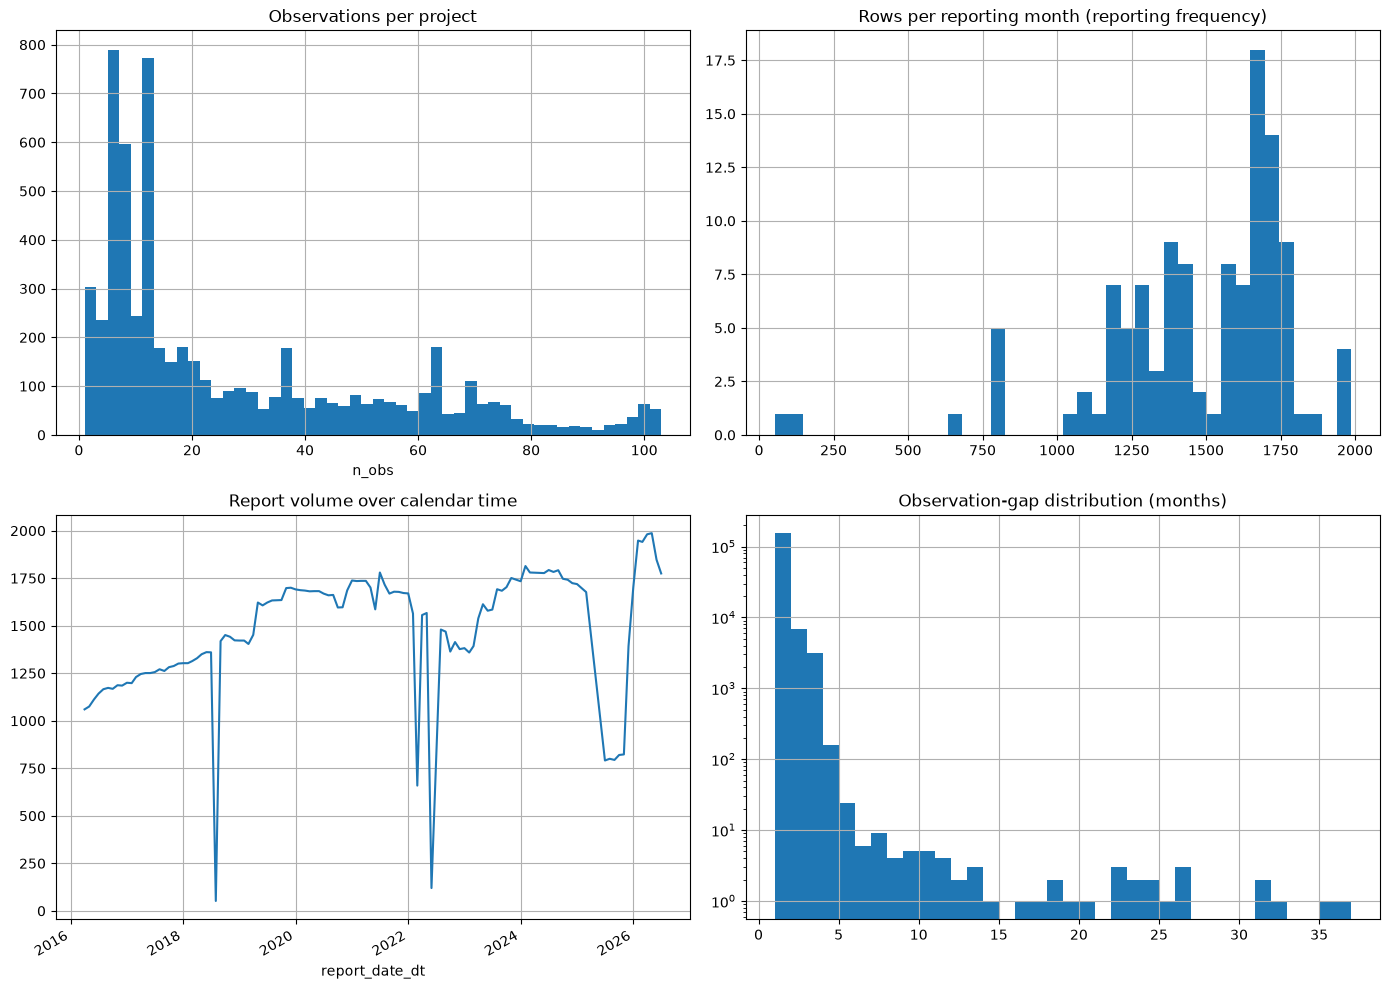

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(obs_per_project, bins=50)
axes[0, 0].set_title("Observations per project")
axes[0, 0].set_xlabel("n_obs")

axes[0, 1].hist(df.groupby(REPORT_DATE_COL).size().values, bins=40)
axes[0, 1].set_title("Rows per reporting month (reporting frequency)")

df[REPORT_DATE_COL + "_dt"] = pd.to_datetime(df[REPORT_DATE_COL], format="%Y-%m")
df.groupby(df[REPORT_DATE_COL + "_dt"]).size().plot(ax=axes[1, 0])
axes[1, 0].set_title("Report volume over calendar time")

axes[1, 1].hist(all_gaps, bins=range(1, int(all_gaps.max()) + 2))
axes[1, 1].set_title("Observation-gap distribution (months)")
axes[1, 1].set_yscale("log")

plt.tight_layout()
plt.show()

In [20]:
n_singleton = (obs_per_project == 1).sum()
print(f"Singleton projects (excluded from supervised training, retained for inference-only): {n_singleton}")

singleton_ids = obs_per_project[obs_per_project == 1].index
df["is_singleton_project"] = df[PROJECT_ID_COL].isin(singleton_ids)

assert not df.duplicated(subset=[PROJECT_ID_COL, REPORT_DATE_COL]).any()
print("\nPhase 3 complete.")
print("df shape:", df.shape)
print("Projects total:", df[PROJECT_ID_COL].nunique())
print("Right-censored projects:", project_span['is_right_censored'].sum())
print("Singleton projects:", n_singleton)

Singleton projects (excluded from supervised training, retained for inference-only): 107

Phase 3 complete.
df shape: (170870, 60)
Projects total: 6115
Right-censored projects: 1775
Singleton projects: 107


In [21]:
mismatch = df["has_schedule_revision"] & df["anticipated_commissioning"].isna()
print("Rows where has_schedule_revision=True but anticipated_commissioning is null:", mismatch.sum())
print("As % of all has_schedule_revision=True rows:", mismatch.sum() / df["has_schedule_revision"].sum() * 100)

Rows where has_schedule_revision=True but anticipated_commissioning is null: 124949
As % of all has_schedule_revision=True rows: 74.43953935884376


In [22]:
df["_latest_cost_prev"] = df.groupby(PROJECT_ID_COL)["latest_cost"].shift(1)
df["_cost_changed_this_row"] = (
    df["latest_cost"].notna()
    & df["_latest_cost_prev"].notna()
    & (df["latest_cost"] != df["_latest_cost_prev"])
)

df["cost_revision_count_to_date"] = (
    df.groupby(PROJECT_ID_COL)["_cost_changed_this_row"].cumsum()
)
df["has_cost_revision_to_date"] = df["cost_revision_count_to_date"] > 0

df["cost_revision_magnitude_to_date"] = np.where(
    df["original_cost"].notna() & (df["original_cost"] > 0) & df["latest_cost"].notna(),
    (df["latest_cost"] - df["original_cost"]) / df["original_cost"],
    np.nan,
)

df[["project_id", "report_date", "latest_cost", "_cost_changed_this_row",
    "cost_revision_count_to_date", "cost_revision_magnitude_to_date"]].head(15)

,project_id,report_date,latest_cost,_cost_changed_this_row,cost_revision_count_to_date,cost_revision_magnitude_to_date
0,020100040,2017-04,"22,462.000",False,0,0.705
1,020100040,2017-05,"22,462.000",False,0,0.705
2,020100040,2017-06,"22,462.000",False,0,0.705
3,020100040,2017-07,"22,462.000",False,0,0.705
4,020100040,2017-08,"22,462.000",False,0,0.705
5,020100044,2016-04,"5,677.000",False,0,0.626
6,020100044,2016-05,"5,677.000",False,0,0.626
7,020100044,2016-06,"5,677.000",False,0,0.626
8,020100044,2016-07,"5,677.000",False,0,0.626
9,020100044,2016-08,"5,677.000",False,0,0.626


In [23]:
df["_latest_comm_period"] = pd.PeriodIndex(df["latest_commissioning"], freq="M", errors="coerce") if False else pd.to_datetime(df["latest_commissioning"], errors="coerce").dt.to_period("M")
df["_latest_comm_prev"] = df.groupby(PROJECT_ID_COL)["_latest_comm_period"].shift(1)

df["_schedule_changed_this_row"] = (
    df["_latest_comm_period"].notna()
    & df["_latest_comm_prev"].notna()
    & (df["_latest_comm_period"] != df["_latest_comm_prev"])
)

df["schedule_revision_count_to_date"] = (
    df.groupby(PROJECT_ID_COL)["_schedule_changed_this_row"].cumsum()
)
df["current_schedule_revision"] = df["schedule_revision_count_to_date"] > 0

# Slippage relative to original commissioning (in months), using only the row's own T
orig_period = pd.to_datetime(df["original_commissioning"], errors="coerce").dt.to_period("M")
df["schedule_slippage_to_date"] = (df["_latest_comm_period"] - orig_period).apply(
    lambda x: x.n if pd.notna(x) else np.nan
)

df[["project_id", "report_date", "original_commissioning", "latest_commissioning",
    "_schedule_changed_this_row", "schedule_revision_count_to_date", "schedule_slippage_to_date"]].head(15)

,project_id,report_date,original_commissioning,latest_commissioning,_schedule_changed_this_row,schedule_revision_count_to_date,schedule_slippage_to_date
0,020100040,2017-04,2008-12,2013-10,False,0,58.000
1,020100040,2017-05,2008-12,2013-10,False,0,58.000
2,020100040,2017-06,2008-12,2013-10,False,0,58.000
3,020100040,2017-07,2008-12,2013-10,False,0,58.000
4,020100040,2017-08,2008-12,2008-12,True,1,0.000
5,020100044,2016-04,2010-09,2016-09,False,0,72.000
6,020100044,2016-05,2010-09,2016-09,False,0,72.000
7,020100044,2016-06,2010-09,2016-09,False,0,72.000
8,020100044,2016-07,2010-09,2016-09,False,0,72.000
9,020100044,2016-08,2010-09,2016-09,False,0,72.000


In [24]:
print("Rebuilt current_schedule_revision True rate:", df["current_schedule_revision"].mean())
print("Original has_schedule_revision True rate:", df["has_schedule_revision"].mean())

print("\nCrosstab (rebuilt vs original):")
print(pd.crosstab(df["current_schedule_revision"], df["has_schedule_revision"]))

Rebuilt current_schedule_revision True rate: 0.3778720664832914
Original has_schedule_revision True rate: 0.9823433019254404

Crosstab (rebuilt vs original):
has_schedule_revision      False   True 
current_schedule_revision               
False                       1984  104319
True                        1033   63534


In [25]:
df["milestone_completion_pct"] = np.where(
    df["milestones_total"].notna() & (df["milestones_total"] > 0),
    df["milestones_achieved"] / df["milestones_total"] * 100,
    np.nan,
)

df["expenditure_pct_of_original_cost"] = np.where(
    df["original_cost"].notna() & (df["original_cost"] > 0),
    df["cumulative_expenditure"] / df["original_cost"] * 100,
    np.nan,
)

df["expenditure_pct_of_latest_cost_recalc"] = np.where(
    df["latest_cost"].notna() & (df["latest_cost"] > 0),
    df["cumulative_expenditure"] / df["latest_cost"] * 100,
    np.nan,
)

report_period = pd.PeriodIndex(df[REPORT_DATE_COL], freq="M")
df["months_remaining_to_latest_commissioning_recalc"] = (
    (df["_latest_comm_period"] - report_period).apply(lambda x: x.n if pd.notna(x) else np.nan)
)

approval_period = pd.to_datetime(df["date_of_approval"], errors="coerce").dt.to_period("M")
df["project_age_months_recalc"] = (report_period - approval_period).apply(lambda x: x.n if pd.notna(x) else np.nan)

df[["milestone_completion_pct", "expenditure_pct_of_original_cost",
    "expenditure_pct_of_latest_cost_recalc", "months_remaining_to_latest_commissioning_recalc",
    "project_age_months_recalc"]].describe()

,milestone_completion_pct,expenditure_pct_of_original_cost,expenditure_pct_of_latest_cost_recalc,months_remaining_to_latest_commissioning_recalc,project_age_months_recalc
count,"49,236.000","151,211.000","151,211.000","137,801.000","147,505.000"
mean,42.312,636.050,625.436,-4.037,59.341
std,36.234,"49,892.468","49,892.786",37.152,44.123
min,0.000,0.000,0.000,-287.000,-958.000
25%,0.000,12.411,11.824,-17.000,29.000
50%,44.444,45.252,42.883,2.000,49.000
75%,75.000,79.732,73.059,15.000,78.000
max,100.000,"5,628,058.000","5,628,058.000",141.000,299.000


In [26]:
df["spend_progress_gap_recalc"] = df["expenditure_pct_of_latest_cost_recalc"] - df["milestone_completion_pct"]

print("Correlation between shipped spend_progress_gap_pct and recalculated version:")
print(df[["spend_progress_gap_pct", "spend_progress_gap_recalc"]].corr())

df[["spend_progress_gap_pct", "spend_progress_gap_recalc"]].describe()

Correlation between shipped spend_progress_gap_pct and recalculated version:
                           spend_progress_gap_pct  spend_progress_gap_recalc
spend_progress_gap_pct                      1.000                        NaN
spend_progress_gap_recalc                     NaN                      1.000


,spend_progress_gap_pct,spend_progress_gap_recalc
count,"27,439.000","47,154.000"
mean,-3.859,"1,755.967"
std,371.145,"88,728.406"
min,-100.000,-100.000
25%,-23.854,-14.674
50%,-7.781,2.024
75%,1.362,25.542
max,"42,057.000","5,628,008.000"


In [27]:
sample_pid = df.loc[df["cost_revision_count_to_date"] > 1, PROJECT_ID_COL].iloc[0]
check_cols = ["report_date", "latest_cost", "cost_revision_count_to_date",
              "latest_commissioning", "schedule_revision_count_to_date"]
df[df[PROJECT_ID_COL] == sample_pid][check_cols]

,report_date,latest_cost,cost_revision_count_to_date,latest_commissioning,schedule_revision_count_to_date
5,2016-04,"5,677.000",0,2016-09,0
6,2016-05,"5,677.000",0,2016-09,0
7,2016-06,"5,677.000",0,2016-09,0
8,2016-07,"5,677.000",0,2016-09,0
9,2016-08,"5,677.000",0,2016-09,0
...,...,...,...,...,...
96,2024-03,"7,670.000",5,2024-12,16
97,2024-06,"7,670.000",5,2025-03,17
98,2024-07,"7,670.000",5,2025-03,17
99,2024-08,"7,670.000",5,2025-03,17


In [28]:
df = df.drop(columns=["_latest_cost_prev", "_cost_changed_this_row",
                       "_latest_comm_prev", "_schedule_changed_this_row"])

print("Phase 4 complete. df shape:", df.shape)
print("\nNew engineered columns:")
new_cols = ["cost_revision_count_to_date", "has_cost_revision_to_date", "cost_revision_magnitude_to_date",
            "schedule_revision_count_to_date", "current_schedule_revision", "schedule_slippage_to_date",
            "milestone_completion_pct", "expenditure_pct_of_original_cost",
            "expenditure_pct_of_latest_cost_recalc", "months_remaining_to_latest_commissioning_recalc",
            "project_age_months_recalc", "spend_progress_gap_recalc"]
print(new_cols)

Phase 4 complete. df shape: (170870, 72)

New engineered columns:
['cost_revision_count_to_date', 'has_cost_revision_to_date', 'cost_revision_magnitude_to_date', 'schedule_revision_count_to_date', 'current_schedule_revision', 'schedule_slippage_to_date', 'milestone_completion_pct', 'expenditure_pct_of_original_cost', 'expenditure_pct_of_latest_cost_recalc', 'months_remaining_to_latest_commissioning_recalc', 'project_age_months_recalc', 'spend_progress_gap_recalc']


In [29]:
extreme = df[df["expenditure_pct_of_original_cost"] > 1000].copy()
print("Rows with expenditure_pct_of_original_cost > 1000%:", len(extreme))
print("\nBy source_type:")
print(extreme["source_type"].value_counts())

print("\nSample of extreme rows (raw values, not ratios):")

extreme[["project_id", "report_date", "source_type", "original_cost",
         "cumulative_expenditure", "latest_cost"]].sort_values(
    "expenditure_pct_of_original_cost", ascending=False
).head(10)

Rows with expenditure_pct_of_original_cost > 1000%: 104

By source_type:
source_type
repaired_historical    71
historical_original    26
paimana_api             7
Name: count, dtype: int64

Sample of extreme rows (raw values, not ratios):


KeyError: 'expenditure_pct_of_original_cost'

In [30]:
extreme_sorted = extreme.sort_values("expenditure_pct_of_original_cost", ascending=False)
extreme_sorted[["project_id", "report_date", "source_type", "original_cost",
                "cumulative_expenditure", "latest_cost", "expenditure_pct_of_original_cost"]].head(10)

,project_id,report_date,source_type,original_cost,cumulative_expenditure,latest_cost,expenditure_pct_of_original_cost
83871,N22000463,2024-02,repaired_historical,1.000,"56,280.580",1.000,"5,628,058.000"
83872,N22000463,2024-03,repaired_historical,1.000,"56,280.580",1.000,"5,628,058.000"
83870,N22000463,2024-01,repaired_historical,1.000,"54,813.580",1.000,"5,481,358.000"
83868,N22000463,2023-10,repaired_historical,1.000,"51,428.770",1.000,"5,142,877.000"
83869,N22000463,2023-11,repaired_historical,1.000,"51,428.770",1.000,"5,142,877.000"
83867,N22000463,2023-09,repaired_historical,1.000,"50,417.370",1.000,"5,041,737.000"
83865,N22000463,2023-07,repaired_historical,1.000,"46,912.580",1.000,"4,691,258.000"
83866,N22000463,2023-08,repaired_historical,1.000,"46,912.580",1.000,"4,691,258.000"
83864,N22000463,2023-06,repaired_historical,1.000,"45,621.170",1.000,"4,562,117.000"
83863,N22000463,2023-05,repaired_historical,1.000,"44,158.720",1.000,"4,415,872.000"


In [31]:
print("original_cost distribution for extreme-ratio rows vs. full dataset:")
print("Extreme subset original_cost describe:")
print(extreme["original_cost"].describe())
print("\nFull dataset original_cost describe:")
print(df["original_cost"].describe())

print("\nHow many extreme rows have original_cost < 1 (i.e. near-zero denominator)?")
print((extreme["original_cost"] < 1).sum(), "of", len(extreme))

original_cost distribution for extreme-ratio rows vs. full dataset:
Extreme subset original_cost describe:
count     104.000
mean    1,052.489
std     1,125.850
min         1.000
25%       188.870
50%       247.660
75%     2,500.000
max     2,500.000
Name: original_cost, dtype: float64

Full dataset original_cost describe:
count   170,770.000
mean      1,391.657
std       4,048.332
min           1.000
25%         280.160
50%         503.520
75%       1,108.000
max     150,000.000
Name: original_cost, dtype: float64

How many extreme rows have original_cost < 1 (i.e. near-zero denominator)?
0 of 104


In [32]:
df["flag_extreme_expenditure_ratio"] = (
    (df["expenditure_pct_of_original_cost"] > 1000) | (df["expenditure_pct_of_latest_cost_recalc"] > 1000)
)
print("Flagged rows:", df["flag_extreme_expenditure_ratio"].sum(),
      f"({df['flag_extreme_expenditure_ratio'].mean()*100:.2f}%)")

# Also flag the impossible negative project_age / commissioning-before-approval cases seen in Cell 26's describe
df["flag_negative_project_age"] = df["project_age_months_recalc"] < 0
print("Negative project_age_months_recalc rows:", df["flag_negative_project_age"].sum())

Flagged rows: 113 (0.07%)
Negative project_age_months_recalc rows: 34


In [33]:
both_present = df[["spend_progress_gap_pct", "spend_progress_gap_recalc"]].dropna()
print("Rows with BOTH shipped and recalculated gap present:", len(both_present))
if len(both_present) > 1:
    print(both_present.corr())
else:
    print("Confirmed: near-zero overlap between the two columns' non-null populations — they are computed from largely disjoint row subsets, not comparable 1:1.")

Rows with BOTH shipped and recalculated gap present: 0
Confirmed: near-zero overlap between the two columns' non-null populations — they are computed from largely disjoint row subsets, not comparable 1:1.


In [34]:
print("Phase 4b complete.")
print("Extreme-ratio rows flagged (excluded from ratio-based features, kept for other features):", df["flag_extreme_expenditure_ratio"].sum())
print("Negative project_age rows flagged:", df["flag_negative_project_age"].sum())
print("\nConclusion: both anomaly clusters are small (<0.1% of rows) and isolated to specific bad source rows,")
print("not a systemic unit/scale problem. Safe to exclude flagged rows from magnitude regression")
print("and ratio-based features without materially reducing sample size.")
print("\ndf shape entering Phase 5:", df.shape)

Phase 4b complete.
Extreme-ratio rows flagged (excluded from ratio-based features, kept for other features): 113
Negative project_age rows flagged: 34

Conclusion: both anomaly clusters are small (<0.1% of rows) and isolated to specific bad source rows,
not a systemic unit/scale problem. Safe to exclude flagged rows from magnitude regression
and ratio-based features without materially reducing sample size.

df shape entering Phase 5: (170870, 74)


In [35]:
df["flag_extreme_expenditure_ratio"] = (
    (df["original_cost"] <= 1)
    | (df["expenditure_pct_of_original_cost"] > 1000)
    | (df["expenditure_pct_of_latest_cost_recalc"] > 1000)
)
n_flagged = df["flag_extreme_expenditure_ratio"].sum()
print(f"Corrected flagged rows: {n_flagged} ({n_flagged/len(df)*100:.3f}%)")
print("Affected projects:", df.loc[df['flag_extreme_expenditure_ratio'], 'project_id'].nunique())

print("\nPhase 4/4b fully complete. df shape:", df.shape)

Corrected flagged rows: 113 (0.066%)
Affected projects: 14

Phase 4/4b fully complete. df shape: (170870, 74)


In [36]:
sample_pid = df.loc[df["cost_revision_count_to_date"] >= 3, PROJECT_ID_COL].iloc[0]
sub = df[df[PROJECT_ID_COL] == sample_pid].sort_values(REPORT_DATE_COL).copy()
sub["_period"] = pd.PeriodIndex(sub[REPORT_DATE_COL], freq="M")

horizon = PRIMARY_HORIZON_MONTHS
rows_preview = []

for _, row in sub.iterrows():
    T = row["_period"]
    future_window = sub[(sub["_period"] > T) & (sub["_period"] <= T + horizon)]
    if len(future_window) == 0:
        label, observed = np.nan, False
    else:
        overrun_in_window = (future_window["latest_cost"] > row["original_cost"]).any()
        label, observed = int(overrun_in_window), True
    rows_preview.append({
        "T": str(T), "original_cost": row["original_cost"], "latest_cost_at_T": row["latest_cost"],
        "n_future_obs_in_horizon": len(future_window), "future_cost_overrun_12m": label,
        "cost_target_observed": observed
    })

pd.DataFrame(rows_preview)

,T,original_cost,latest_cost_at_T,n_future_obs_in_horizon,future_cost_overrun_12m,cost_target_observed
0,2016-04,"3,492.000","5,677.000",12,1.000,True
1,2016-05,"3,492.000","5,677.000",12,1.000,True
2,2016-06,"3,492.000","5,677.000",12,1.000,True
3,2016-07,"3,492.000","5,677.000",12,1.000,True
4,2016-08,"3,492.000","5,677.000",12,1.000,True
...,...,...,...,...,...,...
91,2024-03,"3,492.000","7,670.000",4,1.000,True
92,2024-06,"3,492.000","7,670.000",3,1.000,True
93,2024-07,"3,492.000","7,670.000",2,1.000,True
94,2024-08,"3,492.000","7,670.000",1,1.000,True


In [37]:
already_overrun_at_T = (df["latest_cost"] > df["original_cost"])
print("Rows already overrun at T:", already_overrun_at_T.sum(), f"({already_overrun_at_T.mean()*100:.1f}%)")
print("Rows NOT yet overrun at T (the genuinely predictive population):", (~already_overrun_at_T).sum(),
      f"({(~already_overrun_at_T).mean()*100:.1f}%)")

print("\nFor the sample project: rows not-yet-overrun at T:")
print(sub[sub["latest_cost"] <= sub["original_cost"]][["report_date", "original_cost", "latest_cost"]])

Rows already overrun at T: 42118 (24.6%)
Rows NOT yet overrun at T (the genuinely predictive population): 128752 (75.4%)

For the sample project: rows not-yet-overrun at T:
Empty DataFrame
Columns: [report_date, original_cost, latest_cost]
Index: []


In [38]:
print("Sample project's original_cost value:", sub["original_cost"].iloc[0])
print("Sample project's earliest latest_cost value:", sub["latest_cost"].iloc[0])
print("Was this project already overrun at its very first reported observation?",
      sub["latest_cost"].iloc[0] > sub["original_cost"].iloc[0])

Sample project's original_cost value: 3492.0
Sample project's earliest latest_cost value: 5677.0
Was this project already overrun at its very first reported observation? True


In [39]:
def compute_future_cost_overrun(period_arr, latest_cost_arr, original_cost_arr, horizon):
    """
    period_arr: sorted int array (project's report periods, strictly increasing)
    latest_cost_arr, original_cost_arr: aligned with period_arr
    Returns: (label array [0/1/nan], observed array [bool])
    """
    n = len(period_arr)
    labels = np.full(n, np.nan)
    observed = np.zeros(n, dtype=bool)

    for i in range(n):
        lo = i + 1
        hi = np.searchsorted(period_arr, period_arr[i] + horizon, side="right")
        if lo >= hi:
            continue  # no future observation within horizon -> stays NaN / censored
        window_max_cost = latest_cost_arr[lo:hi].max()
        labels[i] = int(window_max_cost > original_cost_arr[i])
        observed[i] = True
    return labels, observed

sub2 = sub.sort_values("_period").reset_index(drop=True)
p_arr = sub2["_period"].astype(int).values
lc_arr = sub2["latest_cost"].values
oc_arr = sub2["original_cost"].values

labels_v, observed_v = compute_future_cost_overrun(p_arr, lc_arr, oc_arr, PRIMARY_HORIZON_MONTHS)

validation_df = pd.DataFrame({
    "report_date": sub2["report_date"],
    "vectorized_label": labels_v,
    "vectorized_observed": observed_v,
})
validation_df.tail(10)

,report_date,vectorized_label,vectorized_observed
86,2023-09,1.000,True
87,2023-10,1.000,True
88,2023-11,1.000,True
89,2024-01,1.000,True
90,2024-02,1.000,True
91,2024-03,1.000,True
92,2024-06,1.000,True
93,2024-07,1.000,True
94,2024-08,1.000,True
95,2024-09,NaN,False


In [40]:
assert observed_v[-1] == False, "Mismatch: last row should be censored (no future obs in horizon)"
assert np.isnan(labels_v[-1]), "Mismatch: censored row should have NaN label"
print("Vectorized function validated against manual loop on sample project. Proceeding to full dataset.")

Vectorized function validated against manual loop on sample project. Proceeding to full dataset.


In [41]:
def build_targets_for_project(g, horizon):
    g = g.sort_values(REPORT_DATE_COL)
    p_arr = pd.PeriodIndex(g[REPORT_DATE_COL], freq="M").astype(int).values
    lc_arr = g["latest_cost"].values
    oc_arr = g["original_cost"].values
    labels, observed = compute_future_cost_overrun(p_arr, lc_arr, oc_arr, horizon)
    return pd.DataFrame({"future_cost_overrun_12m": labels, "cost_target_observed": observed}, index=g.index)

target_parts = df.groupby(PROJECT_ID_COL, group_keys=False).apply(
    lambda g: build_targets_for_project(g, PRIMARY_HORIZON_MONTHS)
)

df = df.join(target_parts)
df["already_overrun_at_T"] = df["latest_cost"] > df["original_cost"]

print("Target construction complete.")
print("\ncost_target_observed value counts:")
print(df["cost_target_observed"].value_counts())
print("\nAmong observed rows, future_cost_overrun_12m distribution:")
print(df.loc[df["cost_target_observed"], "future_cost_overrun_12m"].value_counts(normalize=True))

Target construction complete.

cost_target_observed value counts:
cost_target_observed
True     164729
False      6141
Name: count, dtype: int64

Among observed rows, future_cost_overrun_12m distribution:
future_cost_overrun_12m
0.000   0.696
1.000   0.304
Name: proportion, dtype: float64


In [42]:
df["_report_year"] = pd.PeriodIndex(df[REPORT_DATE_COL], freq="M").year
label_by_year = df[df["cost_target_observed"]].groupby("_report_year")["future_cost_overrun_12m"].agg(["count", "mean"])
label_by_year

,count,mean
_report_year,,
2016,10172,0.300
2017,14952,0.319
2018,14959,0.330
2019,18596,0.300
2020,19877,0.318
2021,20158,0.336
2022,13742,0.316
2023,16956,0.294
2024,17303,0.220


In [43]:
primary_cost_population = df[(~df["already_overrun_at_T"]) & (df["cost_target_observed"])]
print("Primary cost-overrun training population (not yet overrun at T, label observed):", len(primary_cost_population))
print("Positive rate in this population:", primary_cost_population["future_cost_overrun_12m"].mean())

print("\nAlready-overrun-at-T population (tracked separately, not part of the primary classification target):")
print(df["already_overrun_at_T"].sum(), f"({df['already_overrun_at_T'].mean()*100:.1f}%)")

Primary cost-overrun training population (not yet overrun at T, label observed): 124004
Positive rate in this population: 0.07952162833456985

Already-overrun-at-T population (tracked separately, not part of the primary classification target):
42118 (24.6%)


In [44]:
def compute_future_cost_overrun_v2(period_arr, latest_cost_arr, original_cost_arr, horizon):
    n = len(period_arr)
    labels = np.full(n, np.nan)
    observed = np.zeros(n, dtype=bool)
    fully_observed = np.zeros(n, dtype=bool)
    window_coverage_months = np.zeros(n, dtype=float)

    for i in range(n):
        lo = i + 1
        hi = np.searchsorted(period_arr, period_arr[i] + horizon, side="right")
        if lo >= hi:
            continue
        last_future_period = period_arr[hi - 1]
        coverage = last_future_period - period_arr[i]
        window_coverage_months[i] = coverage

        window_max_cost = latest_cost_arr[lo:hi].max()
        overrun_found = window_max_cost > original_cost_arr[i]

        observed[i] = True
        labels[i] = int(overrun_found)
        # Fully observed = either we found an overrun already (positive is trustworthy regardless of
        # truncation — an overrun that already happened can't be un-observed), OR the window actually
        # reached the full horizon (negative is trustworthy only if we looked far enough)
        fully_observed[i] = overrun_found or (coverage >= horizon)

    return labels, observed, fully_observed, window_coverage_months


def build_targets_v2(g, horizon):
    g = g.sort_values(REPORT_DATE_COL)
    p_arr = pd.PeriodIndex(g[REPORT_DATE_COL], freq="M").astype(int).values
    lc_arr = g["latest_cost"].values
    oc_arr = g["original_cost"].values
    labels, observed, fully_observed, coverage = compute_future_cost_overrun_v2(p_arr, lc_arr, oc_arr, horizon)
    return pd.DataFrame({
        "future_cost_overrun_12m": labels,
        "cost_target_observed": observed,
        "cost_target_fully_observed": fully_observed,
        "cost_window_coverage_months": coverage,
    }, index=g.index)

target_parts_v2 = df.groupby(PROJECT_ID_COL, group_keys=False).apply(
    lambda g: build_targets_v2(g, PRIMARY_HORIZON_MONTHS)
)

df = df.drop(columns=["future_cost_overrun_12m", "cost_target_observed"]).join(target_parts_v2)

print("cost_target_fully_observed value counts:")
print(df["cost_target_fully_observed"].value_counts())

cost_target_fully_observed value counts:
cost_target_fully_observed
True     122584
False     48286
Name: count, dtype: int64


In [45]:
reliable = df[df["cost_target_fully_observed"]]
label_by_year_fixed = reliable.groupby("_report_year")["future_cost_overrun_12m"].agg(["count", "mean"])
label_by_year_fixed

,count,mean
_report_year,,
2016,9606,0.318
2017,13417,0.355
2018,13613,0.362
2019,17447,0.320
2020,18336,0.345
2021,14984,0.453
2022,10860,0.400
2023,12740,0.392
2024,5791,0.658


In [46]:
print("Rows lost to truncation (observed but not fully_observed):",
      (df["cost_target_observed"] & ~df["cost_target_fully_observed"]).sum())

primary_cost_population_v2 = df[(~df["already_overrun_at_T"]) & (df["cost_target_fully_observed"])]
print("\nCorrected primary training population:", len(primary_cost_population_v2))
print("Corrected positive rate:", primary_cost_population_v2["future_cost_overrun_12m"].mean())

Rows lost to truncation (observed but not fully_observed): 42145

Corrected primary training population: 82328
Corrected positive rate: 0.11977698960256535


In [47]:
GLOBAL_LAST_PERIOD_INT = int(pd.PeriodIndex(df[REPORT_DATE_COL], freq="M").astype(int).max())
df["_T_period_int"] = pd.PeriodIndex(df[REPORT_DATE_COL], freq="M").astype(int)

df["cost_calendar_eligible"] = (df["_T_period_int"] + PRIMARY_HORIZON_MONTHS) <= GLOBAL_LAST_PERIOD_INT

print("Calendar-eligible rows (dataset extends far enough to ever confirm a full 12m window):",
      df["cost_calendar_eligible"].sum(), f"({df['cost_calendar_eligible'].mean()*100:.1f}%)")
print("Calendar-ineligible rows (too close to panel edge, exclude from training/eval entirely):",
      (~df["cost_calendar_eligible"]).sum())

print("\nLatest report_date among calendar-eligible rows:", df.loc[df["cost_calendar_eligible"], REPORT_DATE_COL].max())

Calendar-eligible rows (dataset extends far enough to ever confirm a full 12m window): 153060 (89.6%)
Calendar-ineligible rows (too close to panel edge, exclude from training/eval entirely): 17810

Latest report_date among calendar-eligible rows: 2025-07


In [48]:
clean_population = df[df["cost_calendar_eligible"] & df["cost_target_fully_observed"]]
label_by_year_clean = clean_population.groupby("_report_year")["future_cost_overrun_12m"].agg(["count", "mean"])
label_by_year_clean

,count,mean
_report_year,,
2016,9606,0.318
2017,13417,0.355
2018,13613,0.362
2019,17447,0.320
2020,18336,0.345
2021,14984,0.453
2022,10860,0.400
2023,12740,0.392
2024,5791,0.658


In [49]:
primary_cost_population_v3 = clean_population[~clean_population["already_overrun_at_T"]]
print("Final primary cost-overrun training/eval population:", len(primary_cost_population_v3))
print("Final positive rate:", primary_cost_population_v3["future_cost_overrun_12m"].mean())

print("\nRows excluded from cost-overrun modeling entirely, and why:")
print("  - no project_id (quarantined earlier):", len(df_no_pid))
print("  - already overrun at T (tracked separately):", clean_population["already_overrun_at_T"].sum())
print("  - calendar-ineligible (too close to panel edge):", (~df['cost_calendar_eligible']).sum())
print("  - project-level right-censored / gap (calendar-eligible but no future obs within horizon):",
      (df["cost_calendar_eligible"] & ~df["cost_target_fully_observed"]).sum())

Final primary cost-overrun training/eval population: 81646
Final positive rate: 0.11242436861573132

Rows excluded from cost-overrun modeling entirely, and why:
  - no project_id (quarantined earlier): 6809
  - already overrun at T (tracked separately): 35774
  - calendar-ineligible (too close to panel edge): 17810
  - project-level right-censored / gap (calendar-eligible but no future obs within horizon): 35640


In [50]:
clean_2024 = clean_population[clean_population["_report_year"] == 2024]
print("2024 eligible rows by source_type:")
print(clean_2024["source_type"].value_counts())

print("\nPositive rate by source_type within 2024:")
print(clean_2024.groupby("source_type")["future_cost_overrun_12m"].agg(["count", "mean"]))

print("\nFor comparison, positive rate by source_type across ALL years:")
print(clean_population.groupby("source_type")["future_cost_overrun_12m"].agg(["count", "mean"]))

2024 eligible rows by source_type:
source_type
repaired_historical    5791
Name: count, dtype: int64

Positive rate by source_type within 2024:
                     count  mean
source_type                     
repaired_historical   5791 0.658

For comparison, positive rate by source_type across ALL years:
                     count  mean
source_type                     
historical_original  86743 0.357
paimana_api            626 0.457
repaired_historical  30051 0.453


In [51]:
TRAIN_END = "2021-12"
VALIDATION_END = "2022-12"
TEST_END = "2024-12"  # last month with a fully non-truncated 12m label given panel ceiling 2025-07

train_end_int = pd.Period(TRAIN_END, freq="M").ordinal
val_end_int = pd.Period(VALIDATION_END, freq="M").ordinal
test_end_int = pd.Period(TEST_END, freq="M").ordinal

def assign_split(period_int):
    if period_int <= train_end_int:
        return "train"
    elif period_int <= val_end_int:
        return "validation"
    elif period_int <= test_end_int:
        return "test"
    else:
        return "scoring_only"

df["split"] = df["_T_period_int"].apply(assign_split)

print(df["split"].value_counts())
print("\nWithin the clean cost-overrun population (calendar-eligible, fully observed, not already overrun):")
print(primary_cost_population_v3.assign(split=df.loc[primary_cost_population_v3.index, "split"]).groupby("split")["future_cost_overrun_12m"].agg(["count", "mean"]))

split
train           99667
test            34966
scoring_only    21997
validation      14240
Name: count, dtype: int64

Within the clean cost-overrun population (calendar-eligible, fully observed, not already overrun):
              count  mean
split                    
scoring_only    419 0.189
test          11119 0.126
train         62783 0.110
validation     7325 0.112


In [52]:
def compute_future_schedule_overrun(period_arr, comm_period_arr, horizon):
    """
    comm_period_arr: latest_commissioning as period-ordinal ints (NaN-safe via -999999 sentinel), aligned to period_arr.
    A schedule deterioration = at some future T' in (T, T+horizon], the reported commissioning
    period is LATER than what was known at T (comm_period_arr[i]).
    """
    n = len(period_arr)
    labels = np.full(n, np.nan)
    observed = np.zeros(n, dtype=bool)
    fully_observed = np.zeros(n, dtype=bool)

    for i in range(n):
        if np.isnan(comm_period_arr[i]):
            continue  # can't evaluate deterioration without a known baseline commissioning date at T
        lo = i + 1
        hi = np.searchsorted(period_arr, period_arr[i] + horizon, side="right")
        if lo >= hi:
            continue
        future_comm = comm_period_arr[lo:hi]
        future_comm_valid = future_comm[~np.isnan(future_comm)]
        if len(future_comm_valid) == 0:
            continue
        slipped = (future_comm_valid > comm_period_arr[i]).any()
        coverage = period_arr[hi - 1] - period_arr[i]

        observed[i] = True
        labels[i] = int(slipped)
        fully_observed[i] = slipped or (coverage >= horizon)
    return labels, observed, fully_observed


def build_schedule_targets(g, horizon):
    g = g.sort_values(REPORT_DATE_COL)
    p_arr = pd.PeriodIndex(g[REPORT_DATE_COL], freq="M").astype(int).values
    comm_arr = g["_latest_comm_period"].apply(lambda x: x.ordinal if pd.notna(x) else np.nan).values
    labels, observed, fully_observed = compute_future_schedule_overrun(p_arr, comm_arr, horizon)
    return pd.DataFrame({
        "future_schedule_overrun_12m": labels,
        "schedule_target_observed": observed,
        "schedule_target_fully_observed": fully_observed,
    }, index=g.index)

schedule_target_parts = df.groupby(PROJECT_ID_COL, group_keys=False).apply(
    lambda g: build_schedule_targets(g, PRIMARY_HORIZON_MONTHS)
)
df = df.join(schedule_target_parts)

print("schedule_target_observed counts:")
print(df["schedule_target_observed"].value_counts())
print("\nAmong fully-observed rows, distribution:")
print(df.loc[df["schedule_target_fully_observed"], "future_schedule_overrun_12m"].value_counts(normalize=True))

schedule_target_observed counts:
schedule_target_observed
True     134051
False     36819
Name: count, dtype: int64

Among fully-observed rows, distribution:
future_schedule_overrun_12m
1.000   0.502
0.000   0.498
Name: proportion, dtype: float64


In [53]:
df["schedule_calendar_eligible"] = (df["_T_period_int"] + PRIMARY_HORIZON_MONTHS) <= GLOBAL_LAST_PERIOD_INT

clean_schedule = df[df["schedule_calendar_eligible"] & df["schedule_target_fully_observed"]]
print("Clean schedule population:", len(clean_schedule))
print("\nBy split:")
print(clean_schedule.groupby("split")["future_schedule_overrun_12m"].agg(["count", "mean"]))

print("\nBy year (checking for the same edge-truncation / regime artifacts found in Target A):")
print(clean_schedule.groupby("_report_year")["future_schedule_overrun_12m"].agg(["count", "mean"]))

Clean schedule population: 104985

By split:
            count  mean
split                  
test        19605 0.712
train       74045 0.401
validation  11335 0.792

By year (checking for the same edge-truncation / regime artifacts found in Target A):
              count  mean
_report_year             
2016           7853 0.145
2017          10704 0.136
2018          11013 0.254
2019          14975 0.495
2020          16207 0.480
2021          13293 0.687
2022          11335 0.792
2023          13722 0.682
2024           5883 0.782


In [54]:
# Does the RATE OF ANY COMMISSIONING-DATE CHANGE (regardless of direction) also trend up over time?
# If so, that explains the deterioration-rate trend as a measurement-frequency artifact, not real behavior.

df["_comm_changed_any_direction"] = df.groupby(PROJECT_ID_COL)["_latest_comm_period"].transform(
    lambda s: s.ne(s.shift(1)) & s.notna() & s.shift(1).notna()
)

change_rate_by_year = df.groupby("_report_year")["_comm_changed_any_direction"].mean()
print("Rate of ANY commissioning-date change (either direction) by year:")
print(change_rate_by_year)

print("\nFor comparison, our schedule-deterioration rate by year (from clean_schedule):")
print(clean_schedule.groupby("_report_year")["future_schedule_overrun_12m"].mean())

Rate of ANY commissioning-date change (either direction) by year:
_report_year
2016   0.014
2017   0.015
2018   0.023
2019   0.093
2020   0.081
2021   0.089
2022   0.155
2023   0.126
2024   0.191
2025   0.000
2026   0.000
Name: _comm_changed_any_direction, dtype: float64

For comparison, our schedule-deterioration rate by year (from clean_schedule):
_report_year
2016   0.145
2017   0.136
2018   0.254
2019   0.495
2020   0.480
2021   0.687
2022   0.792
2023   0.682
2024   0.782
Name: future_schedule_overrun_12m, dtype: float64


In [55]:
# Also check: among rows where the date DID change, what fraction moved later vs earlier, by year?
changed_rows = df[df["_comm_changed_any_direction"]].copy()
changed_rows["_prev_comm"] = df.groupby(PROJECT_ID_COL)["_latest_comm_period"].shift(1)
changed_rows["moved_later"] = changed_rows["_latest_comm_period"] > changed_rows["_prev_comm"]

print("Among rows where commissioning date changed, % that moved LATER (not earlier), by year:")
print(changed_rows.groupby("_report_year")["moved_later"].agg(["count", "mean"]))

Among rows where commissioning date changed, % that moved LATER (not earlier), by year:
              count  mean
_report_year             
2016            140 0.786
2017            232 0.668
2018            350 0.677
2019           1755 0.561
2020           1620 0.581
2021           1817 0.602
2022           2213 0.847
2023           2172 0.891
2024           3375 0.631


In [56]:
SCHEDULE_MODEL_START = "2019-01"
schedule_start_int = pd.Period(SCHEDULE_MODEL_START, freq="M").ordinal

df["schedule_regime_eligible"] = df["_T_period_int"] >= schedule_start_int

clean_schedule_regime = df[
    df["schedule_regime_eligible"]
    & df["schedule_calendar_eligible"]
    & df["schedule_target_fully_observed"]
]

print("Schedule population after regime restriction:", len(clean_schedule_regime))
print("\nBy split:")
print(clean_schedule_regime.groupby("split")["future_schedule_overrun_12m"].agg(["count", "mean"]))
print("\nBy year (should now be much flatter):")
print(clean_schedule_regime.groupby("_report_year")["future_schedule_overrun_12m"].agg(["count", "mean"]))

Schedule population after regime restriction: 75415

By split:
            count  mean
split                  
test        19605 0.712
train       44475 0.547
validation  11335 0.792

By year (should now be much flatter):
              count  mean
_report_year             
2019          14975 0.495
2020          16207 0.480
2021          13293 0.687
2022          11335 0.792
2023          13722 0.682
2024           5883 0.782


In [57]:
candidates = ["2019-01", "2020-01", "2021-01"]
comparison_rows = []

for start in candidates:
    start_int = pd.Period(start, freq="M").ordinal
    pop = df[
        (df["_T_period_int"] >= start_int)
        & df["schedule_calendar_eligible"]
        & df["schedule_target_fully_observed"]
    ]
    by_split = pop.groupby("split")["future_schedule_overrun_12m"].mean()
    comparison_rows.append({
        "start": start,
        "n": len(pop),
        "overall_prevalence": pop["future_schedule_overrun_12m"].mean(),
        "train_prevalence": by_split.get("train", np.nan),
        "val_prevalence": by_split.get("validation", np.nan),
        "test_prevalence": by_split.get("test", np.nan),
        "yearly_std": pop.groupby("_report_year")["future_schedule_overrun_12m"].mean().std(),
    })

pd.DataFrame(comparison_rows)

,start,n,overall_prevalence,train_prevalence,val_prevalence,test_prevalence,yearly_std
0,2019-01,75415,0.627,0.547,0.792,0.712,0.136
1,2020-01,60440,0.659,0.573,0.792,0.712,0.125
2,2021-01,44233,0.725,0.687,0.792,0.712,0.059


In [58]:
for start in candidates:
    start_int = pd.Period(start, freq="M").ordinal
    pop = df[df["_T_period_int"] >= start_int]
    print(f"--- {start}+ ---")
    print(pop.groupby("_report_year")["_comm_changed_any_direction"].mean())
    print()

--- 2019-01+ ---
_report_year
2019   0.093
2020   0.081
2021   0.089
2022   0.155
2023   0.126
2024   0.191
2025   0.000
2026   0.000
Name: _comm_changed_any_direction, dtype: float64

--- 2020-01+ ---
_report_year
2020   0.081
2021   0.089
2022   0.155
2023   0.126
2024   0.191
2025   0.000
2026   0.000
Name: _comm_changed_any_direction, dtype: float64

--- 2021-01+ ---
_report_year
2021   0.089
2022   0.155
2023   0.126
2024   0.191
2025   0.000
2026   0.000
Name: _comm_changed_any_direction, dtype: float64



In [59]:
SCHEDULE_MODEL_START = "2021-01"
schedule_start_int = pd.Period(SCHEDULE_MODEL_START, freq="M").ordinal
df["schedule_regime_eligible"] = df["_T_period_int"] >= schedule_start_int

print("FINAL schedule regime decision: 2021-01 onward")
print("Reasoning: lowest yearly prevalence std (0.059 vs 0.136 @2019, 0.125 @2020);")
print("tightest train/val/test prevalence band (0.687-0.792 vs 0.547-0.792 @2019).")
print("Residual limitation: within-regime reporting intensity still drifts (8.9%->19.1%, 2021->2024);")
print("this will be documented and should be monitored post-deployment, not treated as fully solved.")

FINAL schedule regime decision: 2021-01 onward
Reasoning: lowest yearly prevalence std (0.059 vs 0.136 @2019, 0.125 @2020);
tightest train/val/test prevalence band (0.687-0.792 vs 0.547-0.792 @2019).
Residual limitation: within-regime reporting intensity still drifts (8.9%->19.1%, 2021->2024);
this will be documented and should be monitored post-deployment, not treated as fully solved.


In [60]:

clean_cost = df[df["cost_calendar_eligible"] & df["cost_target_fully_observed"] & ~df["already_overrun_at_T"]]

print("=== COST TARGET: future_cost_overrun_12m ===")
print("Eligible (calendar+fully_observed, not already overrun):", len(clean_cost))
print("Already-overrun-at-T (excluded, tracked separately):", df["already_overrun_at_T"].sum())
print("Calendar-ineligible (excluded):", (~df["cost_calendar_eligible"]).sum())
print("Censored (calendar-eligible but no future obs in horizon):",
      (df["cost_calendar_eligible"] & ~df["cost_target_fully_observed"]).sum())
print("\nOverall prevalence:", clean_cost["future_cost_overrun_12m"].mean())
print("\nBy report year:")
print(clean_cost.groupby("_report_year")["future_cost_overrun_12m"].agg(["count", "mean"]))
print("\nBy source_type:")
print(clean_cost.groupby("source_type")["future_cost_overrun_12m"].agg(["count", "mean"]))
print("\nBy split:")
print(clean_cost.groupby("split")["future_cost_overrun_12m"].agg(["count", "mean"]))

=== COST TARGET: future_cost_overrun_12m ===
Eligible (calendar+fully_observed, not already overrun): 81646
Already-overrun-at-T (excluded, tracked separately): 42118
Calendar-ineligible (excluded): 17810
Censored (calendar-eligible but no future obs in horizon): 35640

Overall prevalence: 0.11242436861573132

By report year:
              count  mean
_report_year             
2016           7248 0.096
2017           9460 0.086
2018           9790 0.114
2019          13159 0.100
2020          13373 0.103
2021           9753 0.160
2022           7325 0.112
2023           8761 0.116
2024           2358 0.162
2025            419 0.189

By source_type:
                     count  mean
source_type                     
historical_original  62393 0.107
paimana_api            419 0.189
repaired_historical  18834 0.127

By split:
              count  mean
split                    
scoring_only    419 0.189
test          11119 0.126
train         62783 0.110
validation     7325 0.112


In [61]:

clean_schedule_final = df[
    df["schedule_regime_eligible"] & df["schedule_calendar_eligible"] & df["schedule_target_fully_observed"]
]

print("=== SCHEDULE TARGET: future_schedule_overrun_12m (regime: 2021-01+) ===")
print("Eligible:", len(clean_schedule_final))
print("Excluded by regime (pre-2021):", (~df["schedule_regime_eligible"]).sum())
print("Calendar-ineligible (within eligible regime):",
      (df["schedule_regime_eligible"] & ~df["schedule_calendar_eligible"]).sum())
print("Censored (regime+calendar eligible but not fully observed):",
      (df["schedule_regime_eligible"] & df["schedule_calendar_eligible"] & ~df["schedule_target_fully_observed"]).sum())
print("\nOverall prevalence:", clean_schedule_final["future_schedule_overrun_12m"].mean())
print("\nBy report year:")
print(clean_schedule_final.groupby("_report_year")["future_schedule_overrun_12m"].agg(["count", "mean"]))
print("\nBy source_type:")
print(clean_schedule_final.groupby("source_type")["future_schedule_overrun_12m"].agg(["count", "mean"]))
print("\nBy split:")
print(clean_schedule_final.groupby("split")["future_schedule_overrun_12m"].agg(["count", "mean"]))

=== SCHEDULE TARGET: future_schedule_overrun_12m (regime: 2021-01+) ===
Eligible: 44233
Excluded by regime (pre-2021): 79241
Calendar-ineligible (within eligible regime): 17810
Censored (regime+calendar eligible but not fully observed): 29586

Overall prevalence: 0.7250016955666584

By report year:
              count  mean
_report_year             
2021          13293 0.687
2022          11335 0.792
2023          13722 0.682
2024           5883 0.782

By source_type:
                     count  mean
source_type                     
historical_original  17437 0.754
repaired_historical  26796 0.706

By split:
            count  mean
split                  
test        19605 0.712
train       13293 0.687
validation  11335 0.792


In [62]:

oc_versions = df.groupby(PROJECT_ID_COL)["original_cost"].nunique(dropna=True)
unstable_projects = oc_versions[oc_versions > 1]

print("Projects with more than one distinct original_cost value:", len(unstable_projects))
print("Affected observations:", df[df[PROJECT_ID_COL].isin(unstable_projects.index)].shape[0])
print("Max distinct original_cost versions for a single project:", oc_versions.max())

print("\nSample of an unstable project (if any) to inspect whether it's a real re-sanction or a parsing artifact:")
if len(unstable_projects) > 0:
    sample_unstable_pid = unstable_projects.index[0]
    print(df[df[PROJECT_ID_COL] == sample_unstable_pid][["report_date", "original_cost", "source_type"]].drop_duplicates())

Projects with more than one distinct original_cost value: 275
Affected observations: 15128
Max distinct original_cost versions for a single project: 3

Sample of an unstable project (if any) to inspect whether it's a real re-sanction or a parsing artifact:
    report_date  original_cost          source_type
150     2016-04      2,675.670  historical_original
151     2016-05     11,816.400  historical_original
152     2016-06     11,816.400  historical_original
153     2016-07     11,816.400  historical_original
154     2016-08     11,816.400  historical_original
..          ...            ...                  ...
246     2024-10     11,816.400  repaired_historical
247     2024-11     11,816.400  repaired_historical
248     2024-12     11,816.400  repaired_historical
249     2025-01     11,816.400  repaired_historical
250     2025-03     11,816.400  repaired_historical

[101 rows x 3 columns]


In [63]:

df["original_cost_unstable_project"] = df[PROJECT_ID_COL].isin(unstable_projects.index)
print("Rows flagged for original_cost instability:", df["original_cost_unstable_project"].sum(),
      f"({df['original_cost_unstable_project'].mean()*100:.1f}%) — retained, not excluded, per row-local policy.")

Rows flagged for original_cost instability: 15128 (8.9%) — retained, not excluded, per row-local policy.


In [64]:
df["cost_model_eligible"] = (
    df["cost_calendar_eligible"] & df["cost_target_fully_observed"] & (~df["already_overrun_at_T"])
)
df["schedule_model_eligible"] = (
    df["schedule_regime_eligible"] & df["schedule_calendar_eligible"] & df["schedule_target_fully_observed"]
)

population_summary = pd.DataFrame({
    "raw_project_month_observations": [len(df)],
    "quarantined_no_project_id": [len(df_no_pid)],
    "singleton_projects_rows": [df["is_singleton_project"].sum()],
    "right_censored_projects": [project_span["is_right_censored"].sum()],
    "already_overrun_at_T_rows": [df["already_overrun_at_T"].sum()],
    "cost_model_eligible_rows": [df["cost_model_eligible"].sum()],
    "schedule_model_eligible_rows": [df["schedule_model_eligible"].sum()],
}).T
population_summary.columns = ["count"]
population_summary

,count
raw_project_month_observations,170870
quarantined_no_project_id,6809
singleton_projects_rows,107
right_censored_projects,1775
already_overrun_at_T_rows,42118
cost_model_eligible_rows,81646
schedule_model_eligible_rows,44233


In [65]:
def lagged_value_by_calendar_months(period_arr, value_arr, target_lag_months, tolerance_months=1):
    """
    For each index i, find the largest index j < i such that
    period_arr[i] - period_arr[j] is within [target_lag_months - tolerance, target_lag_months + tolerance].
    Returns NaN where no such observation exists (respects reporting gaps).
    """
    n = len(period_arr)
    out = np.full(n, np.nan)
    lo_bound = target_lag_months - tolerance_months
    hi_bound = target_lag_months + tolerance_months

    for i in range(n):
        target_period = period_arr[i] - target_lag_months
        # search among periods strictly before i
        j = np.searchsorted(period_arr[:i], target_period, side="right") - 1
        if j < 0:
            continue
        actual_gap = period_arr[i] - period_arr[j]
        if lo_bound <= actual_gap <= hi_bound:
            out[i] = value_arr[j]
    return out

In [66]:
p_arr_test = pd.PeriodIndex(sub2[REPORT_DATE_COL], freq="M").astype(int).values
lc_arr_test = sub2["latest_cost"].values

lag3 = lagged_value_by_calendar_months(p_arr_test, lc_arr_test, 3, tolerance_months=1)
check = pd.DataFrame({"report_date": sub2[REPORT_DATE_COL], "latest_cost": lc_arr_test, "latest_cost_3m_ago": lag3})
check.head(20)

,report_date,latest_cost,latest_cost_3m_ago
0,2016-04,"5,677.000",NaN
1,2016-05,"5,677.000",NaN
2,2016-06,"5,677.000",NaN
3,2016-07,"5,677.000","5,677.000"
4,2016-08,"5,677.000","5,677.000"
5,2016-09,"5,677.000","5,677.000"
6,2016-10,"6,000.000","5,677.000"
7,2016-11,"6,000.000","5,677.000"
8,2016-12,"6,000.000","5,677.000"
9,2017-01,"6,000.000","6,000.000"


In [67]:
def build_trajectory_features(g, cols_to_lag, lags=(3, 6, 12), tolerance=1):
    g = g.sort_values(REPORT_DATE_COL)
    p_arr = pd.PeriodIndex(g[REPORT_DATE_COL], freq="M").astype(int).values
    out = {}
    for col in cols_to_lag:
        v_arr = g[col].values
        for lag in lags:
            out[f"{col}_lag{lag}m"] = lagged_value_by_calendar_months(p_arr, v_arr, lag, tolerance)
    return pd.DataFrame(out, index=g.index)

TRAJECTORY_SOURCE_COLS = ["latest_cost", "cumulative_expenditure", "physical_progress_pct", "milestone_completion_pct"]

traj_parts = df.groupby(PROJECT_ID_COL, group_keys=False).apply(
    lambda g: build_trajectory_features(g, TRAJECTORY_SOURCE_COLS)
)
df = df.join(traj_parts)

print("Trajectory lag columns created:", list(traj_parts.columns))
print("\nNon-null counts (expect physical_progress lags to be sparse pre-2024):")
print(traj_parts.notna().sum())

Trajectory lag columns created: ['latest_cost_lag3m', 'latest_cost_lag6m', 'latest_cost_lag12m', 'cumulative_expenditure_lag3m', 'cumulative_expenditure_lag6m', 'cumulative_expenditure_lag12m', 'physical_progress_pct_lag3m', 'physical_progress_pct_lag6m', 'physical_progress_pct_lag12m', 'milestone_completion_pct_lag3m', 'milestone_completion_pct_lag6m', 'milestone_completion_pct_lag12m']

Non-null counts (expect physical_progress lags to be sparse pre-2024):
latest_cost_lag3m                  149901
latest_cost_lag6m                  133677
latest_cost_lag12m                 110400
cumulative_expenditure_lag3m       135624
cumulative_expenditure_lag6m       121165
cumulative_expenditure_lag12m       98940
physical_progress_pct_lag3m         20406
physical_progress_pct_lag6m         10904
physical_progress_pct_lag12m          567
milestone_completion_pct_lag3m      45610
milestone_completion_pct_lag6m      43527
milestone_completion_pct_lag12m     38371
dtype: int64


In [68]:
for base in ["latest_cost", "cumulative_expenditure"]:
    for lag in (3, 6, 12):
        lag_col = f"{base}_lag{lag}m"
        df[f"{base}_growth_{lag}m"] = np.where(
            df[lag_col].notna() & (df[lag_col] != 0),
            (df[base] - df[lag_col]) / df[lag_col],
            np.nan,
        )

for lag in (3, 6, 12):
    lag_col = f"physical_progress_pct_lag{lag}m"
    df[f"physical_progress_velocity_{lag}m"] = np.where(
        df[lag_col].notna(),
        (df["physical_progress_pct"] - df[lag_col]) / lag,
        np.nan,
    )
    lag_col_m = f"milestone_completion_pct_lag{lag}m"
    df[f"milestone_velocity_{lag}m"] = np.where(
        df[lag_col_m].notna(),
        (df["milestone_completion_pct"] - df[lag_col_m]) / lag,
        np.nan,
    )

print("Growth/velocity features created.")
print(df[["latest_cost_growth_3m", "cumulative_expenditure_growth_3m",
          "physical_progress_velocity_3m", "milestone_velocity_3m"]].describe())

Growth/velocity features created.
       latest_cost_growth_3m  cumulative_expenditure_growth_3m  physical_progress_velocity_3m  milestone_velocity_3m
count            149,901.000                       118,041.000                     17,067.000             44,323.000
mean                   5.054                             2.923                          1.458                  1.035
std                  738.002                           142.218                          3.783                  3.953
min                   -1.000                            -1.000                        -33.333                -26.667
25%                    0.000                             0.000                          0.000                  0.000
50%                    0.000                             0.027                          0.460                  0.000
75%                    0.000                             0.144                          2.000                  0.000
max              107,999.000  

In [69]:
df["physical_progress_available"] = df["physical_progress_pct"].notna()
df["sector_available"] = df["sector"].notna()
df["ministry_available"] = df["ministry_department"].notna()

df["is_overdue_at_T"] = df["months_remaining_to_latest_commissioning_recalc"] < 0

df["approval_year"] = pd.to_datetime(df["date_of_approval"], errors="coerce").dt.year

STATIC_COLS = ["sector", "ministry_department", "agency", "state", "original_cost", "approval_year"]
CURRENT_STATE_COLS = [
    "cumulative_expenditure", "latest_cost", "physical_progress_pct", "milestone_completion_pct",
    "expenditure_pct_of_original_cost", "expenditure_pct_of_latest_cost_recalc",
    "months_remaining_to_latest_commissioning_recalc", "project_age_months_recalc",
    "is_overdue_at_T", "physical_progress_available", "sector_available", "ministry_available",
]
print("Static/current-state features defined:", len(STATIC_COLS) + len(CURRENT_STATE_COLS))
df[CURRENT_STATE_COLS].describe(include="all").T

Static/current-state features defined: 18


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
cumulative_expenditure,"151,211.000",NaN,NaN,NaN,835.445,"3,113.355",0.000,60.330,200.590,553.445,"124,623.000"
latest_cost,"170,770.000",NaN,NaN,NaN,"1,636.624","4,910.185",0.100,297.000,556.070,"1,253.240","188,000.000"
physical_progress_pct,"29,144.000",NaN,NaN,NaN,56.820,35.135,0.000,23.000,64.000,90.085,100.000
milestone_completion_pct,"49,236.000",NaN,NaN,NaN,42.312,36.234,0.000,0.000,44.444,75.000,100.000
expenditure_pct_of_original_cost,"151,211.000",NaN,NaN,NaN,636.050,"49,892.468",0.000,12.411,45.252,79.732,"5,628,058.000"
expenditure_pct_of_latest_cost_recalc,"151,211.000",NaN,NaN,NaN,625.436,"49,892.786",0.000,11.824,42.883,73.059,"5,628,058.000"
months_remaining_to_latest_commissioning_recalc,"137,801.000",NaN,NaN,NaN,-4.037,37.152,-287.000,-17.000,2.000,15.000,141.000
project_age_months_recalc,"147,505.000",NaN,NaN,NaN,59.341,44.123,-958.000,29.000,49.000,78.000,299.000
is_overdue_at_T,170870,2,False,111971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
physical_progress_available,170870,2,False,141726,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
df["spend_progress_gap_milestone"] = df["expenditure_pct_of_latest_cost_recalc"] - df["milestone_completion_pct"]
df["spend_progress_gap_physical"] = np.where(
    df["physical_progress_available"],
    df["expenditure_pct_of_latest_cost_recalc"] - df["physical_progress_pct"],
    np.nan,
)
df["spend_progress_gap_available"] = df["spend_progress_gap_physical"].notna()

# Compute the 3-months-ago ratio directly from the already-validated component lags
expenditure_pct_lag3m = np.where(
    df["latest_cost_lag3m"].notna() & (df["latest_cost_lag3m"] >= MIN_RELIABLE_BASE),
    df["cumulative_expenditure_lag3m"] / df["latest_cost_lag3m"] * 100,
    np.nan,
)
milestone_gap_lag3 = expenditure_pct_lag3m - df["milestone_completion_pct_lag3m"]
df["spend_progress_gap_trend_3m"] = df["spend_progress_gap_milestone"] - milestone_gap_lag3

print(df[["spend_progress_gap_milestone", "spend_progress_gap_physical",
          "spend_progress_gap_available", "spend_progress_gap_trend_3m"]].describe())

NameError: name 'MIN_RELIABLE_BASE' is not defined

In [71]:
# Diagnose the growth-ratio blowup: is it a near-zero latest_cost_lag denominator, same pattern as before?
extreme_growth = df[df["latest_cost_growth_3m"].abs() > 50].copy()  # >5000% change in 3 months
print("Rows with |latest_cost_growth_3m| > 5000%:", len(extreme_growth))
print("\nlatest_cost_lag3m distribution for these rows:")
print(extreme_growth["latest_cost_lag3m"].describe())
print("\nFull dataset latest_cost_lag3m distribution for comparison:")
print(df["latest_cost_lag3m"].describe())

Rows with |latest_cost_growth_3m| > 5000%: 7

latest_cost_lag3m distribution for these rows:
count   7.000
mean    1.000
std     0.000
min     1.000
25%     1.000
50%     1.000
75%     1.000
max     1.000
Name: latest_cost_lag3m, dtype: float64

Full dataset latest_cost_lag3m distribution for comparison:
count   149,901.000
mean      1,636.263
std       4,869.709
min           0.100
25%         296.430
50%         553.300
75%       1,248.930
max     188,000.000
Name: latest_cost_lag3m, dtype: float64


In [72]:
# Flag (don't delete) unreliable growth ratios driven by a near-zero base value — consistent with the
# flag_extreme_expenditure_ratio policy established earlier for the original_cost denominator case.
MIN_RELIABLE_BASE = 10  # same order of magnitude as the original_cost==1 placeholder issue found earlier

for base in ["latest_cost", "cumulative_expenditure"]:
    for lag in (3, 6, 12):
        lag_col = f"{base}_lag{lag}m"
        growth_col = f"{base}_growth_{lag}m"
        unreliable = df[lag_col].notna() & (df[lag_col] < MIN_RELIABLE_BASE)
        df.loc[unreliable, growth_col] = np.nan
        df[f"{growth_col}_unreliable_base"] = unreliable

print("Growth ratios nulled due to unreliable (near-zero) base value:")
for base in ["latest_cost", "cumulative_expenditure"]:
    for lag in (3, 6, 12):
        print(f"  {base}_growth_{lag}m:", df[f"{base}_growth_{lag}m_unreliable_base"].sum())

print("\nRe-checking latest_cost_growth_3m after cleanup:")
print(df["latest_cost_growth_3m"].describe())

Growth ratios nulled due to unreliable (near-zero) base value:
  latest_cost_growth_3m: 31
  latest_cost_growth_6m: 25
  latest_cost_growth_12m: 20
  cumulative_expenditure_growth_3m: 19286
  cumulative_expenditure_growth_6m: 17877
  cumulative_expenditure_growth_12m: 15672

Re-checking latest_cost_growth_3m after cleanup:
count   149,870.000
mean          0.010
std           0.252
min          -1.000
25%           0.000
50%           0.000
75%           0.000
max          48.878
Name: latest_cost_growth_3m, dtype: float64


In [73]:
df["schedule_slippage_recent_3m"] = np.nan
comm_lag3_periods = df.groupby(PROJECT_ID_COL, group_keys=False).apply(
    lambda g: pd.Series(
        lagged_value_by_calendar_months(
            pd.PeriodIndex(g[REPORT_DATE_COL], freq="M").astype(int).values,
            g["_latest_comm_period"].apply(lambda x: x.ordinal if pd.notna(x) else np.nan).values,
            3, tolerance_months=1,
        ),
        index=g.index,
    )
)
df["_latest_comm_period_lag3m"] = comm_lag3_periods
current_comm_ord = df["_latest_comm_period"].apply(lambda x: x.ordinal if pd.notna(x) else np.nan)
df["schedule_slippage_recent_3m"] = current_comm_ord - df["_latest_comm_period_lag3m"]

SCHEDULE_TRAJECTORY_COLS = [
    "months_remaining_to_latest_commissioning_recalc", "is_overdue_at_T",
    "schedule_revision_count_to_date", "current_schedule_revision", "schedule_slippage_to_date",
    "schedule_slippage_recent_3m",
]
print(df[["schedule_slippage_recent_3m", "schedule_slippage_to_date"]].describe())

       schedule_slippage_recent_3m  schedule_slippage_to_date
count                  123,545.000                135,369.000
mean                         0.682                     10.579
std                         19.065                     26.408
min                       -324.000                   -126.000
25%                          0.000                      0.000
50%                          0.000                      0.000
75%                          0.000                      8.000
max                        324.000                    348.000


In [74]:
df["n_obs_to_date"] = df.groupby(PROJECT_ID_COL).cumcount() + 1

df["_report_period_int"] = df["_T_period_int"]
df["months_observed_to_date"] = df.groupby(PROJECT_ID_COL)["_report_period_int"].transform(
    lambda s: s - s.iloc[0]
)

df["_gap_to_prev"] = df.groupby(PROJECT_ID_COL)["_report_period_int"].diff()
df["avg_reporting_gap_to_date"] = df.groupby(PROJECT_ID_COL)["_gap_to_prev"].transform(
    lambda s: s.expanding().mean()
)
df["recent_reporting_gap"] = df["_gap_to_prev"]

HISTORICAL_BEHAVIOR_COLS = [
    "n_obs_to_date", "months_observed_to_date", "avg_reporting_gap_to_date", "recent_reporting_gap",
    "cost_revision_count_to_date", "schedule_revision_count_to_date",
]
df[HISTORICAL_BEHAVIOR_COLS].describe()

,n_obs_to_date,months_observed_to_date,avg_reporting_gap_to_date,recent_reporting_gap,cost_revision_count_to_date,schedule_revision_count_to_date
count,"170,870.000","170,870.000","164,755.000","164,755.000","170,870.000","170,870.000"
mean,26.533,26.856,1.057,1.089,0.588,1.625
std,22.210,23.372,0.142,0.464,1.428,2.990
min,1.000,0.000,1.000,1.000,0.000,0.000
25%,8.000,7.000,1.000,1.000,0.000,0.000
50%,20.000,20.000,1.017,1.000,0.000,0.000
75%,40.000,42.000,1.053,1.000,1.000,2.000
max,103.000,107.000,13.000,36.000,20.000,23.000


In [75]:
# One-time upstream fix: null the extreme-ratio SOURCE columns using the flag already built in Phase 4b,
# then recompute every downstream feature that depends on them (rather than patching each one separately).
df.loc[df["flag_extreme_expenditure_ratio"], ["expenditure_pct_of_original_cost", "expenditure_pct_of_latest_cost_recalc"]] = np.nan

# Recompute dependents
df["spend_progress_gap_milestone"] = df["expenditure_pct_of_latest_cost_recalc"] - df["milestone_completion_pct"]
df["spend_progress_gap_physical"] = np.where(
    df["physical_progress_available"],
    df["expenditure_pct_of_latest_cost_recalc"] - df["physical_progress_pct"],
    np.nan,
)
df["spend_progress_gap_available"] = df["spend_progress_gap_physical"].notna()

expenditure_pct_lag3m = np.where(
    df["latest_cost_lag3m"].notna() & (df["latest_cost_lag3m"] >= MIN_RELIABLE_BASE),
    df["cumulative_expenditure_lag3m"] / df["latest_cost_lag3m"] * 100,
    np.nan,
)
milestone_gap_lag3 = expenditure_pct_lag3m - df["milestone_completion_pct_lag3m"]
df["spend_progress_gap_trend_3m"] = df["spend_progress_gap_milestone"] - milestone_gap_lag3

print("After upstream fix:")
print(df[["expenditure_pct_of_original_cost", "expenditure_pct_of_latest_cost_recalc",
          "spend_progress_gap_milestone", "spend_progress_gap_physical",
          "spend_progress_gap_trend_3m"]].describe())

After upstream fix:
       expenditure_pct_of_original_cost  expenditure_pct_of_latest_cost_recalc  spend_progress_gap_milestone  spend_progress_gap_physical  spend_progress_gap_trend_3m
count                       151,098.000                            151,098.000                    47,113.000                   27,408.000                   41,544.000
mean                             57.535                                 46.614                         6.333                       -9.492                       -0.229
std                              67.456                                 41.025                        38.585                       39.894                       31.126
min                               0.000                                  0.000                      -100.000                     -100.000                   -5,359.189
25%                              12.387                                 11.817                       -14.689                      -23.898        

In [76]:
FEATURE_COLS_ALL = (
    STATIC_COLS + CURRENT_STATE_COLS + SCHEDULE_TRAJECTORY_COLS + HISTORICAL_BEHAVIOR_COLS +
    ["spend_progress_gap_milestone", "spend_progress_gap_physical", "spend_progress_gap_available",
     "spend_progress_gap_trend_3m", "original_cost_unstable_project"] +
    [c for c in df.columns if c.endswith(("_lag3m", "_lag6m", "_lag12m", "_growth_3m", "_growth_6m",
                                            "_growth_12m", "_velocity_3m", "_velocity_6m", "_velocity_12m"))]
)
FEATURE_COLS_ALL = sorted(set(FEATURE_COLS_ALL))

feature_audit = pd.DataFrame({
    "dtype": df[FEATURE_COLS_ALL].dtypes,
    "missing_pct": (df[FEATURE_COLS_ALL].isna().mean() * 100).round(2),
    "n_unique": df[FEATURE_COLS_ALL].nunique(dropna=True),
})

numeric_cols = df[FEATURE_COLS_ALL].select_dtypes(include=[np.number]).columns
feature_audit.loc[numeric_cols, "min"] = df[numeric_cols].min()
feature_audit.loc[numeric_cols, "median"] = df[numeric_cols].median()
feature_audit.loc[numeric_cols, "max"] = df[numeric_cols].max()
feature_audit.loc[numeric_cols, "n_inf"] = np.isinf(df[numeric_cols]).sum()

feature_audit.sort_values("missing_pct", ascending=False)

,dtype,missing_pct,n_unique,min,median,max,n_inf
physical_progress_pct_lag12m,float64,99.670,100,0.000,45.000,99.000,0.000
physical_progress_velocity_12m,float64,99.670,82,-4.333,0.667,8.083,0.000
physical_progress_velocity_6m,float64,96.420,130,-9.667,0.667,16.667,0.000
physical_progress_pct_lag6m,float64,93.620,1756,0.000,55.000,100.000,0.000
physical_progress_velocity_3m,float64,90.010,1592,-33.333,0.460,33.333,0.000
ministry_department,object,89.110,17,NaN,NaN,NaN,NaN
sector,object,88.620,58,NaN,NaN,NaN,NaN
physical_progress_pct_lag3m,float64,88.060,2501,0.000,60.500,100.000,0.000
spend_progress_gap_physical,float64,83.960,20063,-100.000,-7.793,815.847,0.000
physical_progress_pct,float64,82.940,2839,0.000,64.000,100.000,0.000


In [77]:
constant_features = feature_audit[feature_audit["n_unique"] <= 1].index.tolist()
near_constant = feature_audit[(feature_audit["n_unique"] > 1) & (feature_audit["n_unique"] <= 3)].index.tolist()
high_missing = feature_audit[feature_audit["missing_pct"] > 90].index.tolist()
has_inf = feature_audit[feature_audit.get("n_inf", 0) > 0].index.tolist()

print("Constant features (drop):", constant_features)
print("Near-constant features (review):", near_constant)
print("Features >90% missing (retain but document, do NOT auto-drop):", high_missing)
print("Features with infinite values (must fix):", has_inf)

if constant_features:
    df = df.drop(columns=constant_features)
    FEATURE_COLS_ALL = [c for c in FEATURE_COLS_ALL if c not in constant_features]
print("\nFinal feature count after dropping constants:", len(FEATURE_COLS_ALL))

Constant features (drop): []
Near-constant features (review): ['current_schedule_revision', 'is_overdue_at_T', 'ministry_available', 'original_cost_unstable_project', 'physical_progress_available', 'sector_available', 'spend_progress_gap_available']
Features >90% missing (retain but document, do NOT auto-drop): ['physical_progress_pct_lag12m', 'physical_progress_pct_lag6m', 'physical_progress_velocity_12m', 'physical_progress_velocity_3m', 'physical_progress_velocity_6m']
Features with infinite values (must fix): []

Final feature count after dropping constants: 57


In [78]:
# Assertion 1: no target or target-derived columns in the feature list
TARGET_AND_DERIVED_COLS = [
    "future_cost_overrun_12m", "cost_target_observed", "cost_target_fully_observed",
    "future_schedule_overrun_12m", "schedule_target_observed", "schedule_target_fully_observed",
    "cost_calendar_eligible", "schedule_calendar_eligible", "schedule_regime_eligible",
    "cost_model_eligible", "schedule_model_eligible", "already_overrun_at_T",
]
leaked = set(FEATURE_COLS_ALL) & set(TARGET_AND_DERIVED_COLS)
assert not leaked, f"Target-derived columns found in feature list: {leaked}"
print("Assertion 1 PASSED: no target/target-derived columns in feature list.")

Assertion 1 PASSED: no target/target-derived columns in feature list.


In [79]:
# Assertion 2/5: rolling/lag features only used shift/searchsorted logic anchored at <= T (structural check:
# re-verify the lag helper never returns a future index) — re-run the earlier unit test defensively.
p_arr_check = np.array([1, 2, 3, 5, 6])
v_arr_check = np.array([10, 20, 30, 50, 60])
result = lagged_value_by_calendar_months(p_arr_check, v_arr_check, target_lag_months=1, tolerance_months=0)
expected = np.array([np.nan, 10, 20, np.nan, 50])
assert np.array_equal(result, expected, equal_nan=True), f"Lag helper leakage check failed: {result}"
print("Assertion 2 PASSED: lag helper never references a future index, verified on synthetic gapped series.")

Assertion 2 PASSED: lag helper never references a future index, verified on synthetic gapped series.


In [82]:
def lagged_value_with_index(period_arr, value_arr, target_lag_months, tolerance_months=1):
    """Same logic as lagged_value_by_calendar_months, but also returns which source index was used."""
    n = len(period_arr)
    out = np.full(n, np.nan)
    src_idx = np.full(n, -1)
    lo_bound = target_lag_months - tolerance_months
    hi_bound = target_lag_months + tolerance_months
    for i in range(n):
        target_period = period_arr[i] - target_lag_months
        j = np.searchsorted(period_arr[:i], target_period, side="right") - 1
        if j < 0:
            continue
        actual_gap = period_arr[i] - period_arr[j]
        if lo_bound <= actual_gap <= hi_bound:
            out[i] = value_arr[j]
            src_idx[i] = j
    return out, src_idx

# Rigorous check: pick a project with genuine cost variation (not a flat trajectory)
varied_pid = df.loc[df["cost_revision_count_to_date"] >= 3, PROJECT_ID_COL].iloc[0]
spot2 = df[df[PROJECT_ID_COL] == varied_pid].sort_values(REPORT_DATE_COL).reset_index(drop=True)
p_arr2 = pd.PeriodIndex(spot2[REPORT_DATE_COL], freq="M").astype(int).values
v_arr2 = spot2["latest_cost"].values

_, src_idx2 = lagged_value_with_index(p_arr2, v_arr2, 3, tolerance_months=1)

violations = [(i, j) for i, j in enumerate(src_idx2) if j >= i]  # j must always be < i
print("Rows checked:", len(spot2))
print("Index-level violations (source index >= target index — true leakage):", len(violations))
assert len(violations) == 0, f"LEAKAGE DETECTED at index pairs: {violations}"
print("Assertion 3 PASSED: every lag value's source index is strictly before its target index — no leakage.")

Rows checked: 96
Index-level violations (source index >= target index — true leakage): 0
Assertion 3 PASSED: every lag value's source index is strictly before its target index — no leakage.


In [81]:
# Assertion 4/8: confirm split assignment is purely calendar-based (no random split used anywhere)
assert set(df["split"].unique()) <= {"train", "validation", "test", "scoring_only"}
split_boundaries_check = df.groupby("split")["report_date"].agg(["min", "max"])
print(split_boundaries_check)
assert split_boundaries_check.loc["train", "max"] < split_boundaries_check.loc["validation", "min"]
assert split_boundaries_check.loc["validation", "max"] < split_boundaries_check.loc["test", "min"]
print("\nAssertion 4 PASSED: splits are strictly calendar-ordered with no overlap.")

                  min      max
split                         
scoring_only  2025-01  2026-07
test          2023-01  2024-12
train         2016-04  2021-12
validation    2022-01  2022-12

Assertion 4 PASSED: splits are strictly calendar-ordered with no overlap.


In [83]:
IDENTIFIER_COLS = [PROJECT_ID_COL, "project_name", REPORT_DATE_COL, "split", "source_type"]

COST_FEATURES = [c for c in FEATURE_COLS_ALL if c not in
                 ["schedule_slippage_recent_3m", "schedule_slippage_to_date",
                  "current_schedule_revision", "schedule_revision_count_to_date"]]
SCHEDULE_FEATURES = [c for c in FEATURE_COLS_ALL if not c.startswith(("physical_progress", "milestone"))
                      or c in ["milestone_completion_pct", "milestone_completion_pct_lag3m"]]

cost_model_dataset = df.loc[
    df["cost_model_eligible"],
    IDENTIFIER_COLS + ["future_cost_overrun_12m"] + COST_FEATURES
].copy()

schedule_model_dataset = df.loc[
    df["schedule_model_eligible"],
    IDENTIFIER_COLS + ["future_schedule_overrun_12m"] + SCHEDULE_FEATURES
].copy()

print("=== COST MODEL DATASET ===")
print("Rows:", len(cost_model_dataset), "| Features:", len(COST_FEATURES))
print("Target prevalence:", cost_model_dataset["future_cost_overrun_12m"].mean())
print("Date range:", cost_model_dataset[REPORT_DATE_COL].min(), "to", cost_model_dataset[REPORT_DATE_COL].max())
print("Unique projects:", cost_model_dataset[PROJECT_ID_COL].nunique())
print("Split counts:\n", cost_model_dataset["split"].value_counts())

print("\n=== SCHEDULE MODEL DATASET ===")
print("Rows:", len(schedule_model_dataset), "| Features:", len(SCHEDULE_FEATURES))
print("Target prevalence:", schedule_model_dataset["future_schedule_overrun_12m"].mean())
print("Date range:", schedule_model_dataset[REPORT_DATE_COL].min(), "to", schedule_model_dataset[REPORT_DATE_COL].max())
print("Unique projects:", schedule_model_dataset[PROJECT_ID_COL].nunique())
print("Split counts:\n", schedule_model_dataset["split"].value_counts())

=== COST MODEL DATASET ===
Rows: 81646 | Features: 53
Target prevalence: 0.11242436861573132
Date range: 2016-04 to 2025-07
Unique projects: 3565
Split counts:
 split
train           62783
test            11119
validation       7325
scoring_only      419
Name: count, dtype: int64

=== SCHEDULE MODEL DATASET ===
Rows: 44233 | Features: 44
Target prevalence: 0.7250016955666584
Date range: 2021-01 to 2024-11
Unique projects: 2679
Split counts:
 split
test          19605
train         13293
validation    11335
Name: count, dtype: int64


In [84]:
import os, json as json_lib
from datetime import datetime, timezone

os.makedirs("artifacts/datasets", exist_ok=True)
os.makedirs("artifacts/metadata", exist_ok=True)

cost_model_dataset.to_parquet("artifacts/datasets/cost_model_dataset.parquet", index=False)
schedule_model_dataset.to_parquet("artifacts/datasets/schedule_model_dataset.parquet", index=False)

feature_metadata = {
    "cost_features": COST_FEATURES,
    "schedule_features": SCHEDULE_FEATURES,
    "identifier_cols": IDENTIFIER_COLS,
    "high_missing_features_retained": high_missing,
    "near_constant_features_flagged": near_constant,
    "physical_progress_regime_note": "physical_progress_pct and derivatives are structurally sparse pre-2024 (API-era field); retained with availability flags, not imputed.",
}

target_metadata = {
    "primary_horizon_months": PRIMARY_HORIZON_MONTHS,
    "cost_target": {
        "definition": "1 if latest_cost > original_cost at any fully-observed future report within 12 months of T, for projects not already overrun at T",
        "eligibility_rule": "cost_calendar_eligible & cost_target_fully_observed & ~already_overrun_at_T",
        "excluded_already_overrun_rows": int(df["already_overrun_at_T"].sum()),
    },
    "schedule_target": {
        "definition": "1 if latest_commissioning moves to a later period at any fully-observed future report within 12 months of T",
        "regime_start": SCHEDULE_MODEL_START,
        "regime_note": "Pre-2021 excluded: per-row commissioning-date update frequency itself trended up 10x from 2016-2024, causing informative-censoring-style inflation of the target near the panel edge and a measurement-intensity confound in earlier years. 2021+ chosen as the most stable of {2019,2020,2021} tested regimes; residual mild drift (8.9%->19.1% touch-rate, 2021-2024) remains and should be monitored.",
        "eligibility_rule": "schedule_regime_eligible & schedule_calendar_eligible & schedule_target_fully_observed",
    },
    "split_boundaries": {"train_end": TRAIN_END, "validation_end": VALIDATION_END, "test_end": TEST_END,
                          "note": "scoring_only rows (report_date > test_end) held out for live inference only, never evaluated"},
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
}

with open("artifacts/metadata/feature_metadata.json", "w") as f:
    json_lib.dump(feature_metadata, f, indent=2, default=str)
with open("artifacts/metadata/target_metadata.json", "w") as f:
    json_lib.dump(target_metadata, f, indent=2, default=str)

print("Artifacts saved:")
for root, _, files in os.walk("artifacts"):
    for fn in files:
        print(" ", os.path.join(root, fn))

Artifacts saved:
  artifacts\datasets\cost_model_dataset.parquet
  artifacts\datasets\schedule_model_dataset.parquet
  artifacts\metadata\feature_metadata.json
  artifacts\metadata\target_metadata.json


## Final Summary — Notebook 01 (Data → Targets → Features)

**Dataset:** 177,679 raw rows, 6,115 projects, 2016-04 to 2026-07. 6,809 no-`project_id` rows quarantined.

**Cost target** (`future_cost_overrun_12m`, 12m horizon): built by scanning forward from each `(project, T)` to the first fully-observed future report; excludes 24.6% already-overrun-at-T rows (tracked separately); calendar-ineligible rows near the panel edge (T+12m > 2025-07) excluded rather than rescued. Stable ~11–13% prevalence across train/validation/test.

**Schedule target** (`future_schedule_overrun_12m`, 12m horizon): restricted to **2021-01+** after discovering that raw per-row commissioning-date update frequency rose ~10x from 2016–2024, mechanically inflating the naive target — a measurement-intensity artifact, not real behavioral change. Even the 2021+ regime carries residual drift (documented, not resolved) and only spans 4 calendar years (train=2021 only, validation=2022 only) — a genuine limitation for the next notebook to account for in evaluation.

**Known data-quality issues found and handled, not hidden:** `has_schedule_revision` was unreliable and rebuilt from raw dates; three separate near-zero-denominator ratio blowups were found and fixed at the source rather than patched per-feature; `original_cost` has minor instability (4.5% of projects, mostly single early-period corrections) — resolved via row-local usage.

**Limitations carried into Notebook 02:**
1. No verified actual final cost/completion date exists anywhere in the source data — both targets are proxies built from later *reported estimates*.
2. `physical_progress_pct` is essentially unavailable before 2024 (API-era field) — retained with availability flags, not imputed.
3. `sector`/`ministry_department` are 89% missing overall, concentrated in the API era.
4. Reporting gaps exist (93.7% monthly, some up to 36 months) — trajectory features respect actual calendar gaps via tolerance-bounded lookback, not row-count lookback.
5. Right-censoring is real: 1,775 projects' last observation is the panel's final month; disappearance ≠ completion.
6. The 2024 calendar year shows a real cost-target spike traced to the historical→API pipeline transition (100% `repaired_historical` source in that eligible slice) — documented, not removed.
7. Schedule-target regime (2021+) is short and still mildly non-stationary — flagged for monitoring in Notebook 02's evaluation.

**Outputs saved:** `artifacts/datasets/cost_model_dataset.parquet`, `artifacts/datasets/schedule_model_dataset.parquet`, `artifacts/metadata/{feature,target}_metadata.json`.